# 파트 4 통합 — 건물 · 토지피복 · 사회 데이터 (전체 파이프라인)

2026-08-16 4개 노트북을 실행 순서대로 하나로 합친 버전. 원본은 각각 별도 파일로 남아있고, 이 노트북은 전체 흐름을 한 번에 보고 재현하기 위한 통합본이다.

**실행 순서 (파일 의존성 기준)**

| 구간 | 원본 노트북 | 역할 | 핵심 산출물 |
|---|---|---|---|
| A | `part4_landcover_merge.ipynb` | 세분류 토지피복지도 zip 192개를 하나의 gpkg로 병합한다. `busan_landcover_merged.gpkg`를 산출한다. | - |
| B | `part4_ndvi_export.ipynb` | Sentinel-2 여름 중앙값 NDVI를 GEE에서 산출해 100m로 내려받는다. `ndvi_s2_summer_100m.tif`를 산출한다. | - |
| C | `part4_social_prep.ipynb` | 고령인구·기초생활수급자·독거노인·노후주택 4개 사회지표를 행정동 단위로 정리한다. `dong_social.csv`를 산출한다. | - |
| D | `part4_building_landcover_social.ipynb` | 위 A·B·C의 산출물과 건물통합정보를 hex 격자에 결합해 파트4 최종 산출물 4종을 만든다. | - |

구간 A·B·C는 서로 독립적이고(순서를 바꿔도 무방), D는 A·B·C의 산출 파일을 전부 읽어서 쓰므로 반드시 마지막에 실행해야 한다. 구간 경계마다 `%reset -f`로 네임스페이스를 초기화해 앞 구간 변수가 뒷 구간에 실수로 섞여 들어가지 않게 했다.

---
# 구간 A. 토지피복 병합
**원본: `part4_landcover_merge.ipynb`**

세분류 토지피복지도 zip 192개를 하나의 gpkg로 병합한다. `busan_landcover_merged.gpkg`를 산출한다.

# 파트 4 부속 — 토지피복 세분류 192개 SHP 병합

`data/part4/raw/토지 피복도/부산 열섬/SG05_*_20251113.zip` (192개, 도엽별 세분류 토지피복지도)를
`part4_building_landcover_social.ipynb`의 `rasterize_landcover()`가 바로 읽을 수 있는
**단일 파일**로 합친다.

- 입력: zip 192개 (각 zip 안에 `{도엽8자리}.shp/.dbf/.shx/.prj` + 메타 xml/xlsx)
- 출력: `busan_landcover_merged.gpkg` (전체 병합), `busan_landcover_merged.parquet` (동일 내용, 가벼운 포맷)
- 사전 확인된 사실(2026-08-09 점검):
  - CRS는 전부 동일 `PCS_ITRF2000_TM` = EPSG:5186 (파트4 격자와 일치, 재투영 불필요하지만 명시적으로 고정)
  - 필드: `L1_CODE/L1_NAME, L2_CODE/L2_NAME, L3_CODE/L3_NAME, IMG_DATE, INX_NUM` — `COLMAP["lc"] = {"class": "L3_CODE"}` 그대로 맞음
  - 192개 타일 bounds 합이 파트4 격자 범위를 거의 채움 (부산 전역 커버, 빠진 구역 없음)
  - 총 폴리곤 약 77.5만 개

## 0. 환경 · 상수

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import geopandas as gpd
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# 경로
ZIP_DIR   = Path("../data/part4/raw/토지 피복도/부산 열섬")   # 원본 zip 192개가 있는 폴더
OUT_DIR   = Path("../data/part4/raw/토지 피복도")
OUT_GPKG  = OUT_DIR / "busan_landcover_merged.gpkg"
OUT_PARQ  = OUT_DIR / "busan_landcover_merged.parquet"

# 상수
CRS_GRID = "EPSG:5186"   # 파트4 격자 CRS (2026-08-09 확인: 원본 CRS와 동일 정의, 명시적으로 재고정만 함)

# 파트4 노트북의 격자 범위 - 병합 결과가 이 안에 들어오는지 검산용 (재계산 아님, 그대로 복사)
GRID_BOUNDS = (358000.0, 251800.0, 412200.0, 316200.0)  # XMIN, YMIN, XMAX, YMAX

print("zip 폴더:", ZIP_DIR.resolve())
print("존재 여부:", ZIP_DIR.exists())

zip 폴더: C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\part4\raw\토지 피복도\부산 열섬
존재 여부: True


## 1. zip 목록 확인

In [2]:
zip_paths = sorted(ZIP_DIR.glob("SG05_*_20251113.zip"))
print(f"zip 파일 수: {len(zip_paths)}")
assert len(zip_paths) > 0, "zip을 못 찾음 - ZIP_DIR 경로 확인"

# 파일명에서 도엽번호(8자리) 추출, 중복 파일명 있는지도 같이 확인
tile_ids = [p.stem.split("_")[1] for p in zip_paths]
dup = pd.Series(tile_ids).value_counts()
dup = dup[dup > 1]
print(f"고유 도엽 수: {len(set(tile_ids))}")
if len(dup):
    print("[warn] 파일명이 중복된 도엽:", dup.to_dict())

zip 파일 수: 192
고유 도엽 수: 192


## 2. 개별 zip 읽기 함수

In [3]:
def read_one_tile(zip_path: Path) -> gpd.GeoDataFrame:
    """zip 안의 shp 하나를 읽어 EPSG:5186으로 맞추고 출처 컬럼을 붙인다.

    geopandas는 zip 내부에 최상위 shp가 하나면 `zip://경로.zip` 형태로 바로 읽는다.
    인코딩은 원본이 cp949(euc-kr 계열)라 명시하지 않으면 속성 한글이 깨진다.
    """
    g = gpd.read_file(f"zip://{zip_path}", encoding="cp949")
    if g.crs is None:
        raise ValueError(f"{zip_path.name}: CRS 미선언")
    g = g.to_crs(CRS_GRID)
    g["src_zip"] = zip_path.name
    return g


# 함수 동작 확인 - 첫 zip 하나로 스모크 테스트
_sample = read_one_tile(zip_paths[0])
print(f"샘플({zip_paths[0].name}): {len(_sample)}행, 컬럼={list(_sample.columns)}")
_sample.head(3)

샘플(SG05_34804003_20251113.zip): 7행, 컬럼=['L1_CODE', 'L1_NAME', 'L2_CODE', 'L2_NAME', 'L3_CODE', 'L3_NAME', 'IMG_NAME', 'IMG_DATE', 'LU_INFO', 'ETC_INFO', 'ENV_INFO', 'FOR_INFO', 'UD_INFO', 'INX_NUM', 'geometry', 'src_zip']


,L1_CODE,L1_NAME,L2_CODE,L2_NAME,L3_CODE,L3_NAME,IMG_NAME,IMG_DATE,LU_INFO,ETC_INFO,ENV_INFO,FOR_INFO,UD_INFO,INX_NUM,geometry,src_zip
0,100,시가화건조지역,130,상업지역,131,상업·업무시설,항공정사영상,2024-12-31,None,None,None,None,None,34804003,"POLYGON ((366451.608 268030.085, 366448.579 26...",SG05_34804003_20251113.zip
1,100,시가화건조지역,130,상업지역,131,상업·업무시설,항공정사영상,2024-12-31,None,None,None,None,None,34804003,"POLYGON ((366450.711 268038.537, 366450.222 26...",SG05_34804003_20251113.zip
2,300,산림지역,310,활엽수림,311,활엽수림,항공정사영상,2024-12-31,None,None,None,None,None,34804003,"POLYGON ((366616.076 268319.085, 366603.533 26...",SG05_34804003_20251113.zip


## 3. 전체 병합

In [4]:
frames: list[gpd.GeoDataFrame] = []
failed: list[tuple[str, str]] = []

for i, zp in enumerate(zip_paths, 1):
    try:
        frames.append(read_one_tile(zp))
    except Exception as e:                       # noqa: BLE001 - 한 타일 실패로 전체가 죽으면 안 됨
        failed.append((zp.name, f"{type(e).__name__}: {e}"))
    if i % 20 == 0 or i == len(zip_paths):
        print(f"  {i}/{len(zip_paths)} 처리, 실패 {len(failed)}건")

print()
print(f"성공 {len(frames)}개, 실패 {len(failed)}개")
if failed:
    print("[warn] 실패한 타일:")
    for name, err in failed:
        print(f"  - {name}: {err}")

merged = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=CRS_GRID)
del frames
print(f"병합 결과: {len(merged):,}행 x {merged.shape[1]}열")

  20/192 처리, 실패 0건


  40/192 처리, 실패 0건


  60/192 처리, 실패 0건


  80/192 처리, 실패 0건


  100/192 처리, 실패 0건


...

  140/192 처리, 실패 0건


  160/192 처리, 실패 0건


  180/192 처리, 실패 0건


  192/192 처리, 실패 0건

성공 192개, 실패 0개


병합 결과: 777,559행 x 17열


## 4. 검산

In [5]:
# 1) CRS
assert merged.crs is not None and merged.crs.to_epsg() == 5186, "CRS가 EPSG:5186이 아님"
print(f"[ok] CRS = {merged.crs.to_epsg()}")

# 2) 공간 범위 - 파트4 격자 범위를 크게 벗어나지 않아야 함(약간의 여유는 정상, 도엽이 격자보다 클 수 있음)
b = merged.total_bounds
gx0, gy0, gx1, gy1 = GRID_BOUNDS
print(f"[ok] 병합 bounds = {[round(v) for v in b]}")
print(f"     격자 bounds = {list(GRID_BOUNDS)}")
margin = 3000   # m, 도엽 경계가 격자보다 조금 더 나가는 것까지는 허용
assert (b[0] > gx0 - margin and b[1] > gy0 - margin and
        b[2] < gx1 + margin and b[3] < gy1 + margin), (
    "병합 결과가 파트4 격자 범위를 크게 벗어남 - 좌표계 또는 잘못된 zip 섞임 의심")

# 3) 도엽(INX_NUM) 중복 - 같은 도엽이 두 번 들어갔으면 폴리곤이 두 배로 잡힘
if "INX_NUM" in merged.columns:
    per_tile = merged.groupby("INX_NUM")["src_zip"].nunique()
    bad = per_tile[per_tile > 1]
    if len(bad):
        print(f"[warn] 도엽 하나가 zip 여러 개에서 나옴: {bad.to_dict()}")
    else:
        print(f"[ok] 도엽별 zip 매핑 1:1 ({merged['INX_NUM'].nunique()}개 도엽)")

# 4) 기하 유효성 - 세분류 폴리곤은 자기교차가 드물게 섞여 있음
invalid = ~merged.geometry.is_valid
n_invalid = int(invalid.sum())
print(f"유효하지 않은 지오메트리: {n_invalid}개 ({n_invalid / len(merged):.3%})")
if n_invalid:
    merged.loc[invalid, "geometry"] = merged.loc[invalid, "geometry"].buffer(0)
    still_bad = int((~merged.geometry.is_valid).sum())
    print(f"  buffer(0) 보정 후 남은 것: {still_bad}개")

# 5) 대분류 분포 - 노트북 LC_GREEN_MAJOR/LC_IMPERV_MAJOR/LC_WATER_MAJOR 코드와 맞는지 눈으로 확인
print()
print("L1_CODE 분포:")
print(merged["L1_CODE"].value_counts())
print()
print("L1_NAME 매핑:")
print(merged.drop_duplicates("L1_CODE")[["L1_CODE", "L1_NAME"]].sort_values("L1_CODE"))

[ok] CRS = 5186
[ok] 병합 bounds = [359714, 254916, 411487, 313850]
     격자 bounds = [358000.0, 251800.0, 412200.0, 316200.0]
[warn] 도엽 하나가 zip 여러 개에서 나옴: {'35816010': 2, '35816020': 2, '35816029': 2, '35816048': 2}


유효하지 않은 지오메트리: 1056개 (0.136%)


  buffer(0) 보정 후 남은 것: 0개

L1_CODE 분포:
L1_CODE
100    584284
200     74226
400     69162
600     24037
300     19723
700      3183
500      2944
Name: count, dtype: int64

L1_NAME 매핑:
     L1_CODE  L1_NAME
0        100  시가화건조지역
1699     200     농업지역
2        300     산림지역
35       400       초지
4171     500       습지
4        600       나지
6        700       수역


## 5. 저장

In [6]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

merged.to_parquet(OUT_PARQ, index=False)
print(f"저장: {OUT_PARQ} ({OUT_PARQ.stat().st_size / 1e6:.1f} MB)")

merged.to_file(OUT_GPKG, driver="GPKG")
print(f"저장: {OUT_GPKG} ({OUT_GPKG.stat().st_size / 1e6:.1f} MB)")

print()
print(f"완료 - {len(merged):,}행. "
      f"part4_building_landcover_social.ipynb 의 PATH_LC 를 이 파일로 바꾸면 5단계가 실행됩니다.")
print(f'  예: PATH_LC = Path(r"{OUT_GPKG.resolve()}")')

저장: ..\data\part4\raw\토지 피복도\busan_landcover_merged.parquet (313.0 MB)


저장: ..\data\part4\raw\토지 피복도\busan_landcover_merged.gpkg (578.9 MB)

완료 - 777,559행. part4_building_landcover_social.ipynb 의 PATH_LC 를 이 파일로 바꾸면 5단계가 실행됩니다.
  예: PATH_LC = Path(r"C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\part4\raw\토지 피복도\busan_landcover_merged.gpkg")


In [ ]:
%reset -f
# 2026-08-16: 노트북 병합 시 앞 파트의 변수가 뒷 파트로 잘못 넘어가지 않도록
# 구간마다 네임스페이스를 완전히 초기화한다 (각 파트는 원래 독립 커널에서 돌던
# 노트북이라 파일 입출력으로만 서로 연결되고, 변수 재사용을 전제하지 않는다).


(namespace reset)


---
# 구간 B. NDVI 산출 (GEE)
**원본: `part4_ndvi_export.ipynb`**

Sentinel-2 여름 중앙값 NDVI를 GEE에서 산출해 100m로 내려받는다. `ndvi_s2_summer_100m.tif`를 산출한다.

# 파트 4 부속 — NDVI 산출 (GEE, Sentinel-2)

가이드라인 §2: 최근 5년 6~8월 구름마스킹 중앙값 NDVI, 10m → 100m 집계. 파트1과 같은 GEE 환경에서 산출(별도 다운로드 불필요).

산출물: `data/part4/processed/ndvi_s2_summer_100m.tif` (EPSG:5186, 100m, 파트1·2·4 공통 격자와 동일)

In [8]:
import ee, geemap
import rasterio
from pathlib import Path

import os; GCP_PROJECT = os.environ.get("GEE_PROJECT", "your-gcp-project-id")
try:
    ee.Initialize(project=GCP_PROJECT)
except Exception:
    ee.Authenticate(); ee.Initialize(project=GCP_PROJECT)

BUSAN_BBOX   = (128.74, 34.85, 129.32, 35.42)     # 파트1과 동일 (W,S,E,N EPSG:4326)
CRS_ANALYSIS = "EPSG:5186"
TARGET_RES_M = 100
YEARS        = [2021, 2022, 2023, 2024, 2025]      # 파트1 DAY_YEARS와 동일
SUMMER_MONTHS = (6, 9)                              # 6~8월 (end exclusive)

OUT_DIR = Path("../data/part4/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_TIF = OUT_DIR / "ndvi_s2_summer_100m.tif"

AOI = ee.Geometry.Rectangle(list(BUSAN_BBOX), "EPSG:4326", False)
print("GEE 초기화 완료, AOI:", BUSAN_BBOX)

GEE 초기화 완료, AOI: (128.74, 34.85, 129.32, 35.42)


## 구름마스킹 — s2cloudless 확률 기반

QA60 밴드는 2022년 이후 처리 baseline에서 신뢰도가 떨어진다고 알려져 있어(GEE 커뮤니티에서 흔히 지적되는 이슈), `COPERNICUS/S2_CLOUD_PROBABILITY`(s2cloudless) 컬렉션을 조인해서 확률 50% 초과를 구름으로 마스킹한다.

In [9]:
S2_SR = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
S2_CLOUD = ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")


def summer_range(y):
    return ee.Filter.date(f"{y}-{SUMMER_MONTHS[0]:02d}-01", f"{y}-{SUMMER_MONTHS[1]:02d}-01")


date_filter = ee.Filter.Or(*[summer_range(y) for y in YEARS])

s2_sr_col = S2_SR.filterBounds(AOI).filter(date_filter)
s2_cld_col = S2_CLOUD.filterBounds(AOI).filter(date_filter)

joined = ee.Join.saveFirst("s2cloudless").apply(
    primary=s2_sr_col, secondary=s2_cld_col,
    condition=ee.Filter.equals(leftField="system:index", rightField="system:index"),
)
joined_col = ee.ImageCollection(joined)
print("필터링된 장면 수:", joined_col.size().getInfo())


def add_ndvi_masked(img):
    img = ee.Image(img)
    cld_prb = ee.Image(img.get("s2cloudless")).select("probability")
    not_cloud = cld_prb.lt(50)
    ndvi = img.normalizedDifference(["B8", "B4"]).rename("ndvi")
    return ndvi.updateMask(not_cloud)


ndvi_col = joined_col.map(add_ndvi_masked)
ndvi_median = ndvi_col.median().clip(AOI).toFloat()
print("NDVI 중앙값 합성 완료")

필터링된 장면 수: 385
NDVI 중앙값 합성 완료


## 100m 로컬 다운로드

파트1의 `geemap.download_ee_image()` 패턴과 동일 — 비동기 배치 익스포트 없이 직접 동기 다운로드 (격자가 542×644로 작아서 가능함).

In [10]:
if not OUT_TIF.exists():
    geemap.download_ee_image(ndvi_median, filename=str(OUT_TIF), region=AOI.bounds(),
                             scale=TARGET_RES_M, crs=CRS_ANALYSIS, dtype="float32")
print("저장:", OUT_TIF.resolve())

with rasterio.open(OUT_TIF) as src:
    arr = src.read(1)
    print("shape:", arr.shape, "| crs:", src.crs, "| transform:", src.transform)
    import numpy as np
    valid = np.isfinite(arr) & (arr != src.nodata if src.nodata is not None else True)
    print(f"유효 픽셀 {valid.sum():,} / {arr.size:,} ({valid.mean():.1%})")
    print(f"NDVI 평균 {arr[valid].mean():.3f}, 중앙값 {np.median(arr[valid]):.3f}")

저장: C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\part4\processed\ndvi_s2_summer_100m.tif
shape: (644, 542) | crs: EPSG:5186 | transform: | 100.00, 0.00, 358000.00|
| 0.00,-100.00, 316200.00|
| 0.00, 0.00, 1.00|
유효 픽셀 335,657 / 349,048 (96.2%)
NDVI 평균 0.279, 중앙값 0.042


In [ ]:
%reset -f
# 2026-08-16: 노트북 병합 시 앞 파트의 변수가 뒷 파트로 잘못 넘어가지 않도록
# 구간마다 네임스페이스를 완전히 초기화한다 (각 파트는 원래 독립 커널에서 돌던
# 노트북이라 파일 입출력으로만 서로 연결되고, 변수 재사용을 전제하지 않는다).


(namespace reset)


---
# 구간 C. 사회통계 준비
**원본: `part4_social_prep.ipynb`**

고령인구·기초생활수급자·독거노인·노후주택 4개 사회지표를 행정동 단위로 정리한다. `dong_social.csv`를 산출한다.

# 파트 4 부속 — 행정동 사회통계 3개 파일 → dong_social.csv 병합

파트4 노트북의 `COLMAP["social"]`이 기대하는 컬럼(행정동코드/행정동명/총인구/65세이상인구/기초생활수급자수/
독거노인수/주택수/30년이상주택수)에 맞춰, 확보된 원본 3개를 재구조화·병합한다.

- `부산광역시_행정동별_65세이상인구.csv` (2025.12): KOSIS 원본 그대로라 헤더가 3줄 피벗 구조로 깨져 있음 → reshape.
  총계/65세이상 2행, 행정동 206개.
- `202312_부산광역시_행정동별_65세이상인구.csv`: 65세이상 행 없이 총인구만 있음 → 이번엔 안 씀(2025.12 파일로 총인구/65세이상 둘 다 확보되므로 중복).
- `기초생활보장 수급자 읍면동 현황_20231231.csv`: tidy. 연도 2021~2023 중 최신(2023)만 사용, 구 자체 소계 행 제외,
  5개 유형(일반/조건부/특례/기타/시설) 수급권자수 합산.
- 매칭: `adm_dong_lut.csv`(206개 행정동, adm_cd/sgg_cd/adm_nm)에 동 이름으로 조인 (동명 중복 없음 확인됨).
- **없는 지표**: 독거노인수, 30년이상주택수(노후주택) — 원본 미확보. NaN으로 남김.
- **기준연도가 다름**: 인구 2025.12, 기초수급 2023.12 — 어쩔 수 없는 부분(사용자 확인).

## 0. 환경 · 상수

In [12]:
from __future__ import annotations

import csv
from pathlib import Path

import pandas as pd

P4 = Path("../data/part4/raw")  # 2026-08-16: data/part 4 -> data/part4/raw
LUT_PATH = Path("../data/part1/tables/adm_dong_lut.csv")
OUT_PATH = P4 / "dong_social.csv"

PATH_POP65   = P4 / "부산광역시_행정동별_65세이상인구.csv"
PATH_BASIC   = P4 / "부산광역시_기초생활보장 수급자 읍면동 현황_20231231.csv"

lut = pd.read_csv(LUT_PATH)
print(f"행정동 LUT: {len(lut)}개, 컬럼 {list(lut.columns)}")
assert lut["adm_nm"].is_unique, "동 이름 중복 있음 - 구 이름까지 같이 매칭해야 함"


행정동 LUT: 206개, 컬럼 ['idx', 'adm_cd', 'sgg_cd', 'adm_nm']


## 1. 65세이상인구(2025.12) reshape

In [13]:
with open(PATH_POP65, encoding="utf-8") as f:
    rows = list(csv.reader(f))

# row0=기간(중복블록 있음, 앞 절반만 씀) row1=구명 row2=동명 row3=구분 row4=총계 row5=65세이상
gu_row, dong_row, val_row, val65_row = rows[1], rows[2], rows[4], rows[5]
n_id = 2
period_row = rows[0]

# "2025.12" 라벨이 붙은 첫 블록의 길이 = 뒤 중복 블록 시작 전까지
first_label = period_row[n_id]
block_len = 0
for v in period_row[n_id:]:
    if v == first_label:
        block_len += 1
    else:
        break
print(f"기간 라벨 '{first_label}' 블록 길이: {block_len} (뒤에 중복 블록 있으면 절반만 사용)")

idx = list(range(n_id, n_id + block_len))
pop65 = pd.DataFrame({
    "gu": [gu_row[i] for i in idx],
    "dong": [dong_row[i] for i in idx],
    "pop_total": [int(val_row[i]) for i in idx],
    "pop_65plus": [int(val65_row[i]) for i in idx],
})
# 부산시 총계 행 + 구 소계 행("소계") 제외 - 개별 동만
pop65 = pop65[pop65["dong"] != "소계"].reset_index(drop=True)
print(f"개별 행정동 행 수: {len(pop65)}")
pop65.head()

기간 라벨 '2025.12' 블록 길이: 223 (뒤에 중복 블록 있으면 절반만 사용)
개별 행정동 행 수: 206


,gu,dong,pop_total,pop_65plus
0,중구,중앙동,3083,521
1,중구,동광동,2286,970
2,중구,대청동,5477,1848
3,중구,보수동,9798,3237
4,중구,부평동,3977,1587


## 2. 기초생활수급자(2023, 최신) 집계

In [14]:
basic = pd.read_csv(PATH_BASIC, encoding="cp949")
basic = basic[basic["연도"] == basic["연도"].max()].copy()
print(f"사용 연도: {basic['연도'].iloc[0]}")

# 구 자체 소계 행(읍면동 == 시군구) 제외 - 개별 동만
basic = basic[basic["읍면동"] != basic["시군구"]].copy()

recip_cols = [c for c in basic.columns if c.endswith("수급권자수")]
print(f"합산할 컬럼: {recip_cols}")
basic["basic_recip"] = basic[recip_cols].sum(axis=1)

basic_agg = basic[["시군구", "읍면동", "basic_recip"]].rename(
    columns={"시군구": "gu", "읍면동": "dong"})
print(f"개별 행정동 행 수: {len(basic_agg)}")
basic_agg.head()

사용 연도: 2023
합산할 컬럼: ['일반수급자 수급권자수', '조건부수급자 수급권자수', '특례수급자 수급권자수', '기타 수급권자수', '시설수급자 수급권자수']
개별 행정동 행 수: 206


,gu,dong,basic_recip
446,중구,중앙동,182
447,중구,동광동,464
448,중구,대청동,714
449,중구,보수동,1209
450,중구,부평동,543


## 2-1. 독거노인 현황 (2026-08-16 추가)

부산광역시 공공데이터포털 오픈API("부산광역시_구군 독거노인 현황조회 서비스", `getLaSenior`)에서 16개 구·군 전체를 받아온 원본(`부산광역시_구군_독거노인현황.csv`). 구마다 응답 형식이 달라 정제가 필요함:
- 완전 중복 행 제거(강서구·북구·사상구 일부가 동일 행을 두 번 반환)
- `부산광역시 OO구 ` 접두어 제거(강서구·해운대구만 이렇게 반환)
- `OO제N동` → `OON동` 표기 정규화(서구·북구·해운대구), 단 `거제N동`처럼 정규화하면 안 되는 동은 원래 이름이 LUT에 있으면 그대로 우선 매칭해서 보호
- 영도구가 반환한 소계 행("총 합") 제외
- **기준일자가 구마다 다름**(2025-12-31 ~ 2026-05-27, 각 구청이 독립적으로 갱신) — 단일 시점 스냅샷이 아님, 메타에 기록
- 부산진구(20개 동)는 이 API에서 연령/성별 세부값 없이 합계(`laSeniorCnt`)만 제공 — 총계는 쓸 수 있음

In [15]:
PATH_LA_SENIOR = P4 / "부산광역시_구군_독거노인현황.csv"

la = pd.read_csv(PATH_LA_SENIOR, encoding="utf-8-sig")
la = la.drop_duplicates(subset=["gugun", "dongNm"]).copy()

la["c1"] = (la["dongNm"].str.replace(r"^부산광역시\s*\S+(구|군)\s*", "", regex=True)
                        .str.replace(r"\s+", "", regex=True))
agg_mask = la["c1"].str.contains("총") & la["c1"].str.contains("합")
la = la[~agg_mask].copy()
la["c2"] = la["c1"].str.replace(r"제(\d)", r"\1", regex=True)   # "OO제N동" -> "OON동" 후보

lut_names = set(lut["adm_nm"])
la["adm_nm"] = la["c1"].where(la["c1"].isin(lut_names), la["c2"])
unmatched = la.loc[~la["adm_nm"].isin(lut_names), ["gugun", "dongNm"]]
assert unmatched.empty, f"독거노인 데이터 동명 매칭 실패: {unmatched.values.tolist()}"
assert la["adm_nm"].is_unique, "독거노인 데이터에 동 중복 있음"

la_senior = la[["adm_nm", "laSeniorCnt", "referenceDate"]].rename(
    columns={"laSeniorCnt": "elderly_alone"})
print(f"독거노인 데이터 {len(la_senior)}개 동 매칭 완료 (기대 {len(lut)})")
print(f"기준일자 분포: {la['referenceDate'].value_counts(dropna=False).to_dict()}")
print(f"부산 전체 독거노인수 합계: {la_senior.elderly_alone.sum():,.0f}")

독거노인 데이터 206개 동 매칭 완료 (기대 206)
기준일자 분포: {'2026-04-30': 74, '2025-12-31': 51, '2026-05-27': 27, '2026-05-19': 21, nan: 20, '2026-05-01': 13}
부산 전체 독거노인수 합계: 287,269


## 2-2. 노후주택비율 (2026-08-16 추가)

SGIS 집계구 통계 `21_2024년_건축년도별주택.csv`(long format: 기준년도/집계구코드/`ho_yr_XXX`/값)를 사용.
코드 정의는 `ref_code/3. 제공용 코드(statistics_code).xls`로 확정함 — 2024년 데이터는 "2015~2023" 스킴과 일치:
`ho_yr_001`=1979년 이전, `002`=1980~1989, `003`=1990~1999, `004`=2000~2004, `005`=2005~2009, `006`~`020`=2010~2024(매년 1개씩).

**근사 방법**: 2024년 기준 "30년 이상 경과"는 1994년 이전 건축인데, 원본 구간이 1990~1999로 10년 단위라 1994년에서 정확히 못 끊는다. 그 구간(`ho_yr_003`) 안에서 건축연도가 균등분포한다고 가정해 **절반(1990~1994)만 노후주택으로 계산**한다.
```
노후주택수(근사) = ho_yr_001 + ho_yr_002 + 0.5 * ho_yr_003
```
집계구코드(`oa_cd`, 14자리) 앞 8자리가 행정동코드(`adm_cd`)와 동일해서(206/206 확인됨) 공간조인 없이 `oa_cd[:8]`로 groupby만 하면 됨.

In [16]:
PATH_HOUSING = P4 / "21_2024년_건축년도별주택.csv"

housing = pd.read_csv(PATH_HOUSING, header=None, names=["year", "oa_cd", "code", "value"], dtype=str)
# 원본 "N/A"는 비밀보호 처리(집계구 통계값 5 미만 마스킹) — 판다스 기본 read_csv가 이미 NaN으로 인식,
# sum(skipna=True) 기본값이라 합계에서 자연스럽게 0으로 취급됨(과소추정 소지는 있으나 달리 보정할 방법 없음).
housing["value"] = pd.to_numeric(housing["value"], errors="coerce")
housing["adm_cd"] = housing["oa_cd"].str[:8]

ho_wide = housing.pivot_table(index="adm_cd", columns="code", values="value", aggfunc="sum")
house_old_approx = (ho_wide.get("ho_yr_001", 0).fillna(0)
                    + ho_wide.get("ho_yr_002", 0).fillna(0)
                    + 0.5 * ho_wide.get("ho_yr_003", 0).fillna(0))
house_total = ho_wide.filter(like="ho_yr_").fillna(0).sum(axis=1)

housing_agg = pd.DataFrame({
    "adm_cd": ho_wide.index,
    "house_total": house_total.values,
    "house_old_approx": house_old_approx.values,
})
housing_agg["adm_cd"] = housing_agg["adm_cd"].astype(int)  # LUT의 adm_cd가 int64라 dtype 맞춤(선행0 없는 8자리라 안전)
print(f"주택 데이터 {len(housing_agg)}개 동 매칭 (기대 {len(lut)})")
print(f"노후주택비율(근사) describe:\n{(housing_agg.house_old_approx / housing_agg.house_total).describe()}")

주택 데이터 206개 동 매칭 (기대 206)
노후주택비율(근사) describe:
count    206.000000
mean       0.390480
std        0.193569
min        0.000000
25%        0.235990
50%        0.382324
75%        0.523924
max        0.974522
dtype: float64


## 3. 병합 · LUT 조인

In [17]:
social = pop65.merge(basic_agg[["dong", "basic_recip"]], on="dong", how="outer")

merged = lut.merge(social, left_on="adm_nm", right_on="dong", how="left")
merged = merged.merge(la_senior, on="adm_nm", how="left")
merged = merged.merge(housing_agg, on="adm_cd", how="left")
n_matched = merged["dong"].notna().sum()
print(f"LUT {len(lut)}개 중 매칭: {n_matched}개")
if n_matched < len(lut):
    unmatched = merged[merged["dong"].isna()]["adm_nm"].tolist()
    print(f"[warn] 미매칭 행정동: {unmatched}")

# 사용 안 된 원본 행(구/동 이름이 LUT에 없는 경우) 확인
unused_pop = set(pop65["dong"]) - set(merged["adm_nm"])
unused_basic = set(basic_agg["dong"]) - set(merged["adm_nm"])
if unused_pop:
    print(f"[warn] 인구 파일에만 있고 LUT엔 없는 동: {unused_pop}")
if unused_basic:
    print(f"[warn] 기초수급 파일에만 있고 LUT엔 없는 동: {unused_basic}")

LUT 206개 중 매칭: 206개
[warn] 기초수급 파일에만 있고 LUT엔 없는 동: {'일광면'}


## 4. 파트4 COLMAP 규격에 맞춰 최종 컬럼 정리 · 저장

In [18]:
out = pd.DataFrame({
    "행정동코드":   merged["adm_cd"],
    "행정동명":     merged["adm_nm"],
    "총인구":       merged["pop_total"],
    "65세이상인구": merged["pop_65plus"],
    "기초생활수급자수": merged["basic_recip"],
    "독거노인수":     merged["elderly_alone"],   # 2026-08-16: 부산시 오픈API(getLaSenior)로 확보
    "주택수":         merged["house_total"],       # 2026-08-16: SGIS 건축년도별주택 확보
    "30년이상주택수": merged["house_old_approx"],  # 2026-08-16: ho_yr_001+002+0.5*003 근사
})

out["고령인구비율"] = (out["65세이상인구"] / out["총인구"]).round(4)
out["독거노인비율"] = (out["독거노인수"] / out["총인구"]).round(4)
out["노후주택비율"] = (out["30년이상주택수"] / out["주택수"]).round(4)

print(f"저장 행 수: {len(out)}")
print(f"독거노인수 결측: {out['독거노인수'].isna().sum()}개 동")
print(f"독거노인비율 describe:\n{out['독거노인비율'].describe()}")
print(f"노후주택비율 describe:\n{out['노후주택비율'].describe()}")
print(f"고령인구비율 describe:\n{out['고령인구비율'].describe()}")
print(f"고령비율 상위 5개 동 (기대: 원도심 - 동구·서구·영도구):")
print(out.sort_values('고령인구비율', ascending=False)[['행정동명','고령인구비율']].head(10).to_string(index=False))

out.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUT_PATH.resolve()}")

저장 행 수: 206
독거노인수 결측: 0개 동
독거노인비율 describe:
count    206.000000
mean       0.108720
std        0.071503
min        0.014700
25%        0.062700
50%        0.088800
75%        0.136950
max        0.461200
Name: 독거노인비율, dtype: float64
노후주택비율 describe:
count    206.000000
mean       0.390477
std        0.193570
min        0.000000
25%        0.236000
50%        0.382300
75%        0.523925
max        0.974500
Name: 노후주택비율, dtype: float64
고령인구비율 describe:
count    206.000000
mean       0.286431
std        0.083891
min        0.094800
25%        0.230400
50%        0.278900
75%        0.341050
max        0.506700
Name: 고령인구비율, dtype: float64
고령비율 상위 5개 동 (기대: 원도심 - 동구·서구·영도구):
행정동명  고령인구비율
 가락동  0.5067
 남포동  0.4614
모라3동  0.4612
감천2동  0.4604
 초장동  0.4593
 신선동  0.4562
수정4동  0.4552
대저1동  0.4532
동삼3동  0.4467
선두구동  0.4373

저장 완료: C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\part4\raw\dong_social.csv


In [ ]:
%reset -f
# 2026-08-16: 노트북 병합 시 앞 파트의 변수가 뒷 파트로 잘못 넘어가지 않도록
# 구간마다 네임스페이스를 완전히 초기화한다 (각 파트는 원래 독립 커널에서 돌던
# 노트북이라 파일 입출력으로만 서로 연결되고, 변수 재사용을 전제하지 않는다).


(namespace reset)


---
# 구간 D. 건물·피복·사회 통합 (메인)
**원본: `part4_building_landcover_social.ipynb`**

위 A·B·C의 산출물과 건물통합정보를 hex 격자에 결합해 파트4 최종 산출물 4종을 만든다.

# 파트 4 — 건물 · 토지피복 · 사회 데이터 전처리

**2026 부산광역시 빅데이터 활용 경진대회 · 모델 1(평지형 표준모델)의 변수 전체**

파트 4는 상대 진영의 변호사를 최선을 다해 세워주는 작업이다.
모델 1이 부실하면 "지형을 넣으니 설명력이 올랐다"(ΔR²)는 핵심 주장이
"건물 변수를 대충 만들어서 그렇다"는 반박에 무너진다.

산출물

| 파일 | 컬럼 |
|---|---|
| `part4_building_hex.parquet` | `hex_id, bcr, vol_density, bldg_h_mean, bldg_h_max, svf_total, svf_building_effect, wind_open_sw, n_bldg, h_imputed_frac` |
| `part4_landcover_hex.parquet` | `hex_id, green_frac, imperv_frac, ndvi_s2, albedo, lc_year` |
| `part4_social_dong.csv` | `adm_cd, adm_nm, pop, elderly_rate_dong, basic_recip_rate_dong, elderly_alone_dong, old_house_rate_dong` |
| `part4_meta.json` | 출처·연도 · 높이 보정 규칙 · 피복 매핑 · 감률 민감도 · 상관행렬 |

> **상태: 데이터 미확보.** 경로/컬럼 매핑(1번 셀)만 실제 파일에 맞추면 위에서 아래로 실행된다.
> 3단계(SVF)는 파트 2의 DEM·`svf_terrain`을 기다려야 하므로, 1·2·5단계를 먼저 돌리면 된다.

## 0. 환경 · 상수

```bash
pip install numpy pandas geopandas shapely rasterio pyproj h3 scipy matplotlib pyarrow
```

In [20]:
from __future__ import annotations

import json
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# ── 경로 (2026-08-10, 실제 폴더 구조에 맞춰 수정) ───────────────────────────
ROOT     = Path("../data")  # 2026-08-16: notebooks/ 로 이동
P4       = ROOT / "part4" / "raw"      # 파트4 원본 데이터(건물/피복/사회통계) (2026-08-16: data/part 4 -> data/part4/raw)
LST_DIR  = ROOT / "part1"              # 파트1 산출물 (2026-08-16: data/지표면 온도 데이터 -> data/part1)
DEM_DIR  = ROOT / "part2"              # 파트2 산출물 (2026-08-16: data/전처리용 DEM -> data/part2)
OUT      = ROOT / "part4" / "processed"  # 이 노트북이 새로 만드는 결과물 (2026-08-16: data/part4_outputs -> data/part4/processed, part4/raw와 짝 맞춤)
INTERIM  = OUT / "interim"
OUT.mkdir(parents=True, exist_ok=True)
INTERIM.mkdir(parents=True, exist_ok=True)

PATH_BLDG      = P4 / "AL_D010_26_20260719.shp"                                    # GIS건물통합정보 (2026-07-19)
PATH_LC        = P4 / "토지 피복도" / "busan_landcover_merged.gpkg"                # 토지피복 세분류 192타일 병합본 (gpd.read_file은 parquet 미지원이라 gpkg로)
PATH_NDVI      = ROOT / "part4" / "processed" / "ndvi_s2_summer_100m.tif"           # 2026-08-16: part4_ndvi_export.ipynb 산출물 연결
PATH_SOCIAL    = P4 / "dong_social.csv"                                            # part4_social_prep.ipynb 산출물
PATH_ILLNESS   = P4 / "dong_illness.csv"  # 로더 미구현 - 아직 없는 경로라 자동 skip.
                                            # 원본은 "토지 피복도/부산 열섬/(250923) 시군구별 온열질환 현황.xls"에
                                            # 있지만(2026-08-09 확인) 이 노트북은 pd.read_csv로만 읽게 돼 있어
                                            # xls -> 시군구별 csv 전처리가 먼저 필요함(선택 항목, 별도 요청 시 작업)

# 파트 2 정밀 DEM(5m)은 원본 자체가 90m 해상도뿐이라 존재하지 않음(2026-08-10 확인, .img 6개 타일 직접 조회).
# 더 세밀한 DEM을 구할 수 없다는 전제하에, 있는 것 중 가장 정교한 90m 원본을 100m 격자로 그리드화한 결과로 대체한다.
# → build_dsm()이 이 파일을 bilinear로 재투영하므로 실행은 되지만, 건물 스케일(5~10m) 지형 굴곡은 반영되지 않는다.
PATH_DEM       = DEM_DIR / "processed" / "busan_dem_100m.tif"                      # 정밀 DEM 대체재(90m 기반, 해상도 한계 있음)
PATH_SVF_TER   = DEM_DIR / "processed" / "busan_svf_terrain_100m.tif"              # 파트 2 SVF 지형분 (2026-08-10 생성)
PATH_HEX       = LST_DIR / "tables" / "part1_lst_hex_r10.parquet"                  # 파트 1 hex 테이블 (hex_id/adm_cd/adm_nm)
PATH_DONG_LUT  = LST_DIR / "tables" / "adm_dong_lut.csv"                           # 행정동 LUT (206개)
PATH_LST_NIGHT = LST_DIR / "processed" / "busan_lst_night_median_100m.tif"         # 감률 민감도용 야간 합성 LST
PATH_DEM_100   = DEM_DIR / "processed" / "busan_dem_100m.tif"                      # 감률 민감도용 100m 표고

# ── 격자 규격 (파트 1·3과 반드시 동일) ──────────────────────────────────────
CRS_GRID  = "EPSG:5186"
CRS_WGS84 = "EPSG:4326"
GRID_RES  = 100
GRID_W, GRID_H = 542, 644
XMIN, YMIN, XMAX, YMAX = 358000.0, 251800.0, 412200.0, 316200.0
H3_RES    = 10

from rasterio.transform import from_origin
GRID_TRANSFORM = from_origin(XMIN, YMAX, GRID_RES, GRID_RES)   # row0 = 북쪽

# ── 파라미터 ────────────────────────────────────────────────────────────────
BLDG_AGG_METHOD = "raster10m"   # "overlay"(면적가중 분할, 정확·느림) | "raster10m"(10m 래스터, 빠름·오차 1%)
FLOOR_HEIGHT_M  = 3.0           # 높이 결측 → 층수 × 3m (가이드라인 리스크표 명시)
SVF_RES         = 10            # SVF 계산 해상도(m). 반드시 5~10m. 100m에서 계산하면 전부 1 근처로 뭉개짐
SVF_N_DIR       = 16            # SVF 방위 분할 수
SVF_RADIUS_M    = 100           # 수평선 탐색 반경
WIND_DIR_DEG    = 225           # 여름 주풍향(남서)
WIND_FETCH_M    = 500           # 상류 탐색 거리
LAPSE_P1_NIGHT  = -0.4961       # 파트 1 야간 감률 (°C/100m)
LAPSE_TOL       = 0.05          # ±0.05 이내면 파트 1 anomaly 그대로 확정
N_DONG_EXPECTED = 206           # 파트 1 hex 테이블의 행정동 수

# ── 원본 컬럼명 매핑 (2026-08-10, 실제 데이터에 맞춰 수정) ─────────────────
COLMAP = {
    "bldg":   {"floors": "A26", "height": "__NO_HEIGHT_FIELD__", "usage": "A9",
               "bldg_id": "A21", "area": "A12"},
    # A26=지상층수, A9=주용도명, A21=건물고유번호PK, A12=건축면적(㎡).
    # 높이(m) 필드가 원본에 없음 - 매핑 안 되는 이름을 그대로 둬서 impute_height()가
    # "컬럼 없음" 경고를 내고 전체 건물을 층수×3m로 보정하도록 의도한 것(2026-08-09 확인).
    "lc":     {"class": "L3_CODE"},          # 세분류 코드. 중분류 보완 시 L2_CODE
    "social": {"adm_cd": "행정동코드", "adm_nm": "행정동명", "pop": "총인구",
               "elderly": "65세이상인구", "basic_recip": "기초생활수급자수",
               "elderly_alone": "독거노인수", "house_total": "주택수",
               "house_old": "30년이상주택수"},
    # 독거노인수/주택수/30년이상주택수는 원본 미확보 - dong_social.csv에 NaN으로 들어있음.
}

# 토지피복 세분류 대분류 코드(첫 자리) → 우리 변수
#   1 시가화건조지역 / 2 농업지역 / 3 산림지역 / 4 초지 / 5 습지 / 6 나지 / 7 수역
LC_GREEN_MAJOR   = {"3", "4"}          # 산림·초지 (+ 아래 도시공원 세분류 코드 추가)
LC_IMPERV_MAJOR  = {"1"}               # 시가화·건조지역
LC_GREEN_EXTRA_L3 = {"140"}            # 도시공원·녹지 계열 세분류 코드 (2026-08-09 확인: L2=140/문화체육휴양지역이
                                        # L3=141/문화체육휴양시설 하나뿐이라 공원만 따로 뗄 세분류 코드가 없음 - 보완용이라 없어도 무방)
LC_WATER_MAJOR   = {"7"}

# 피복 클래스별 알베도 문헌 대표값 (정식 Landsat 산출 대신 사용 시)
ALBEDO_BY_MAJOR = {"1": 0.13, "2": 0.18, "3": 0.12, "4": 0.20,
                   "5": 0.10, "6": 0.25, "7": 0.06}

META: dict = {"generated_at": pd.Timestamp.now().isoformat(timespec="seconds"),
              "grid": {"crs": CRS_GRID, "res_m": GRID_RES, "shape": [GRID_H, GRID_W],
                       "bounds": [XMIN, YMIN, XMAX, YMAX]},
              "params": {"floor_height_m": FLOOR_HEIGHT_M, "svf_res_m": SVF_RES,
                         "svf_n_dir": SVF_N_DIR, "svf_radius_m": SVF_RADIUS_M,
                         "wind_dir_deg": WIND_DIR_DEG, "wind_fetch_m": WIND_FETCH_M,
                         "bldg_agg_method": BLDG_AGG_METHOD},
              "sources": {}}

print("격자:", CRS_GRID, GRID_RES, f"{GRID_W}x{GRID_H}")


격자: EPSG:5186 100 542x644


In [21]:
import geopandas as gpd
import h3
import rasterio
from pyproj import Transformer
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.warp import reproject
from shapely.geometry import box

TF_TO_WGS = Transformer.from_crs(CRS_GRID, CRS_WGS84, always_xy=True)


def rename_cols(gdf, colmap: dict):
    ren = {}
    for std, raw in colmap.items():
        if raw in gdf.columns:
            ren[raw] = std
        else:
            cand = [c for c in gdf.columns if c.upper() == raw.upper()]
            if cand:
                ren[cand[0]] = std
    return gdf.rename(columns=ren)


# 2026-08-10: 파트1과 hex_id 부여 방식을 통일 ───────────────────────────────
# 파트1 실제 hex 테이블(part1_LST_final.ipynb cell27)은 100m 셀 하나를 2x2 서브포인트
# (50m 간격)로 쪼개 각 서브포인트마다 hex_id를 매긴 뒤 groupby.mean() 한다. 셀 중심
# 1점만 쓰면 경계에 걸친 hex가 통째로 누락되는데, 서브샘플링을 하면 한 100m 셀의 값이
# 최대 4개 인접 hex에 걸쳐 기여할 수 있어 파트1의 151,440개 hex_id 공간을 훨씬 촘촘히
# 재현한다(1점 방식은 커버율 92.7%에서 멈췄음, 2026-08-10 확인).
SUB = 2   # 파트1과 동일


def subcell_centers_lonlat(sub: int = SUB):
    """100m 셀을 sub x sub 서브셀로 나눈 각 서브셀 중심의 경위도."""
    fine_res = GRID_RES / sub
    cx = XMIN + (np.arange(GRID_W * sub) + 0.5) * fine_res
    cy = YMAX - (np.arange(GRID_H * sub) + 0.5) * fine_res
    X, Y = np.meshgrid(cx, cy)                      # (H*sub, W*sub)
    lon, lat = TF_TO_WGS.transform(X.ravel(), Y.ravel())
    return lon.reshape(GRID_H * sub, GRID_W * sub), lat.reshape(GRID_H * sub, GRID_W * sub)


LON_SUB, LAT_SUB = subcell_centers_lonlat()
HEX_ID_GRID_SUB = np.array(
    [h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(LAT_SUB.ravel(), LON_SUB.ravel())]
).reshape(GRID_H * SUB, GRID_W * SUB)
HEX_ID_GRID = HEX_ID_GRID_SUB[::SUB, ::SUB]   # 100m 격자용(하위 호환) - 셀 중심 hex_id
n_hex_raw = len(np.unique(HEX_ID_GRID_SUB))
print(f"{SUB}x{SUB} 서브샘플링 hex_id 부여 완료: {HEX_ID_GRID_SUB.shape} | 고유 hex 수(필터 전): {n_hex_raw:,}")

# 파트1 실제 hex 테이블은 여기에 더해 land_frac>0(바다만인 hex 제외)로도 걸러서 151,440개다.
# 파트4엔 land_frac이 없으므로, 파트1의 공식 hex_id 목록 자체를 화이트리스트로 걸어
# 두 파트가 같은 hex_id 공간을 쓰게 만든다.
if PATH_HEX.exists():
    HEX_ID_WHITELIST = set(pd.read_parquet(PATH_HEX, columns=["hex_id"])["hex_id"])
    n_kept = len(set(np.unique(HEX_ID_GRID_SUB)) & HEX_ID_WHITELIST)
    print(f"파트1 공식 hex_id {len(HEX_ID_WHITELIST):,}개 화이트리스트 적용 "
          f"→ 겹치는 hex {n_kept:,}개 (파트1 대비 {n_kept/len(HEX_ID_WHITELIST):.1%} 커버)")
else:
    HEX_ID_WHITELIST = None
    print("[warn] PATH_HEX 없음 — hex_id 화이트리스트 미적용, 파트1과 다른 hex 세트로 남음")


def grid_to_hex(arrays: dict, how: str = "mean") -> pd.DataFrame:
    """100m 격자 배열들(dict[name] = (H,W))을 hex_id 로 집계.

    파트1과 동일하게 SUBxSUB 서브그리드(50m)로 확장(각 100m 값을 그대로 반복 — 100m가
    원래 계산 해상도라 더 세밀한 정보는 없음)한 뒤 서브포인트의 hex_id로 묶어 평균한다.
    HEX_ID_WHITELIST가 있으면 파트1 hex_id 세트로 제한해 조인 가능하게 만든다.
    """
    df = pd.DataFrame({"hex_id": HEX_ID_GRID_SUB.ravel()})
    for k, v in arrays.items():
        arr = np.asarray(v, dtype="float64")
        arr_sub = np.repeat(np.repeat(arr, SUB, axis=0), SUB, axis=1)
        df[k] = arr_sub.ravel()
    if HEX_ID_WHITELIST is not None:
        df = df[df["hex_id"].isin(HEX_ID_WHITELIST)]
    g = df.groupby("hex_id")
    out = getattr(g, how)() if how != "sum" else g.sum()
    return out.reset_index()


def write_grid_tif(path: Path, arr: np.ndarray, transform=None, res=GRID_RES, nodata=np.nan):
    transform = transform if transform is not None else GRID_TRANSFORM
    with rasterio.open(path, "w", driver="GTiff", height=arr.shape[0], width=arr.shape[1],
                       count=1, dtype="float32", crs=CRS_GRID, transform=transform,
                       nodata=nodata, compress="deflate") as dst:
        dst.write(arr.astype("float32"), 1)
    return path


def shift_view(a: np.ndarray, dr: int, dc: int, fill=np.nan) -> np.ndarray:
    """result[r, c] = a[r + dr, c + dc] (범위 밖은 fill).

    dr > 0 = 남쪽(row 증가), dc > 0 = 동쪽(col 증가) 방향의 이웃을 본다.
    np.roll은 방향이 반대라 부호 실수가 잦으므로 슬라이싱으로 명시한다.
    """
    H, W = a.shape
    out = np.full_like(a, fill, dtype="float32")
    r0d, r1d = max(0, -dr), min(H, H - dr)
    c0d, c1d = max(0, -dc), min(W, W - dc)
    if r0d < r1d and c0d < c1d:
        out[r0d:r1d, c0d:c1d] = a[r0d + dr:r1d + dr, c0d + dc:c1d + dc]
    return out


def read_to_grid(path: Path, resampling=Resampling.average) -> np.ndarray:
    """임의 래스터를 우리 100m 격자에 정확히 맞춰 리샘플링."""
    dst = np.full((GRID_H, GRID_W), np.nan, dtype="float32")
    with rasterio.open(path) as src:
        reproject(source=rasterio.band(src, 1), destination=dst,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=GRID_TRANSFORM, dst_crs=CRS_GRID,
                  resampling=resampling, src_nodata=src.nodata, dst_nodata=np.nan)
    return dst

2x2 서브샘플링 hex_id 부여 완료: (1288, 1084) | 고유 hex 수(필터 전): 312,668


파트1 공식 hex_id 151,440개 화이트리스트 적용 → 겹치는 hex 151,440개 (파트1 대비 100.0% 커버)


## 1단계 — 건물 SHP 점검

**좌표계는 믿지 말 것.** `.prj`가 실제 좌표와 다르게 적힌 경우가 실무에서 드물지 않다.
건물통합정보는 제공처에 따라 5174·5186 등이 섞여 나온다. 확인 없이 쓰면 수백 m 어긋난다.
→ 변환 후 **부산시청 좌표로 눈 검산**한다.

높이 결측 처리 순서: `높이` → 없으면 `층수 × 3m` → 층수도 없으면 `용도별 중앙값`.
보정된 행에는 `h_imputed` 플래그를 남긴다.

In [22]:
LANDMARKS = {   # 좌표계 검산용 (WGS84 lon, lat)
    "부산시청":       (129.0756, 35.1798),
    "부산역":         (129.0403, 35.1151),
    "해운대 마린시티": (129.1400, 35.1560),
}


def load_buildings(path: Path = PATH_BLDG) -> gpd.GeoDataFrame:
    if not path.exists():
        print("[skip] 건물 SHP 없음")
        return gpd.GeoDataFrame(geometry=[], crs=CRS_GRID)

    g = gpd.read_file(path)
    print(f"원본 {len(g):,}동, 선언 CRS = {g.crs}")
    if g.crs is None:
        raise ValueError("CRS 미선언. 제공처 문서에서 5174/5186 확인 후 g.set_crs()로 지정할 것")
    g = rename_cols(g, COLMAP["bldg"]).to_crs(CRS_GRID)

    # 좌표계 눈 검산 — 랜드마크가 부산 격자 안, 그리고 건물이 있어야 할 곳에 있는지
    verify_crs(g)

    g = g[g.geometry.notna() & ~g.geometry.is_empty].copy()
    g["geometry"] = g.geometry.buffer(0)               # self-intersection 정리

    # 격자 범위 밖 건물 제거 (cx = 공간인덱스 기반 bbox 필터, overlay보다 훨씬 빠름)
    g = g.cx[XMIN:XMAX, YMIN:YMAX].copy()
    g["foot_area"] = g.geometry.area
    print(f"격자 범위 내 {len(g):,}동")
    return g


def verify_crs(g: gpd.GeoDataFrame) -> None:
    tf = Transformer.from_crs(CRS_WGS84, CRS_GRID, always_xy=True)
    sidx = g.sindex
    for name, (lon, lat) in LANDMARKS.items():
        x, y = tf.transform(lon, lat)
        inside = (XMIN <= x < XMAX) and (YMIN <= y < YMAX)
        near = len(list(sidx.intersection((x - 200, y - 200, x + 200, y + 200))))
        print(f"  [CRS 검산] {name}: ({x:,.0f}, {y:,.0f}) 격자내={inside}, 반경200m 건물 {near}동")
        assert inside, f"{name}가 격자 밖 — 좌표계 어긋남"
        if near == 0:
            print(f"  [warn] {name} 주변에 건물이 없음 → 좌표계 재확인 (5174 vs 5186)")


def impute_height(g: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if len(g) == 0:
        return g
    for c in ("height", "floors"):
        if c not in g.columns:
            print(f"[warn] '{c}' 컬럼 없음 — COLMAP['bldg'] 매핑 확인")
            g[c] = np.nan
        g[c] = pd.to_numeric(g[c], errors="coerce")
    g.loc[g.height <= 0, "height"] = np.nan
    g.loc[(g.floors <= 0) | (g.floors > 200), "floors"] = np.nan

    n = len(g)
    miss_h0 = int(g.height.isna().sum())
    miss_f0 = int(g.floors.isna().sum())

    g["h_source"] = "raw"
    # ① 높이 결측 → 층수 × 3m
    m = g.height.isna() & g.floors.notna()
    g.loc[m, "height"] = g.loc[m, "floors"] * FLOOR_HEIGHT_M
    g.loc[m, "h_source"] = "floors_x3"
    # ② 층수도 결측 → 용도별 중앙값
    if "usage" in g.columns:
        med = g.groupby("usage")["height"].transform("median")
    else:
        med = pd.Series(np.nan, index=g.index)
    m = g.height.isna()
    g.loc[m, "height"] = med[m]
    g.loc[m & g.height.notna(), "h_source"] = "usage_median"
    # ③ 그래도 결측 → 전체 중앙값
    m = g.height.isna()
    g.loc[m, "height"] = float(g.height.median())
    g.loc[m, "h_source"] = "global_median"

    g["h_imputed"] = g.h_source != "raw"
    g["height"] = g.height.clip(1, 350)

    log = {"n_buildings": n,
           "height_missing_rate_raw": miss_h0 / n,
           "floors_missing_rate_raw": miss_f0 / n,
           "imputed_rate": float(g.h_imputed.mean()),
           "by_source": g.h_source.value_counts().to_dict(),
           "height_stats": {k: float(v) for k, v in g.height.describe().items()}}
    META["sources"]["building"] = {"path": str(PATH_BLDG), **log}
    print(json.dumps(log, ensure_ascii=False, indent=2))
    return g


bldg = impute_height(load_buildings())

원본 472,607동, 선언 CRS = EPSG:5186


  [CRS 검산] 부산시청: (389,076, 289,016) 격자내=True, 반경200m 건물 158동
  [CRS 검산] 부산역: (386,007, 281,770) 격자내=True, 반경200m 건물 252동
  [CRS 검산] 해운대 마린시티: (395,001, 286,499) 격자내=True, 반경200m 건물 10동


격자 범위 내 472,607동
[warn] 'height' 컬럼 없음 — COLMAP['bldg'] 매핑 확인
{
  "n_buildings": 472607,
  "height_missing_rate_raw": 1.0,
  "floors_missing_rate_raw": 0.38913939065650743,
  "imputed_rate": 1.0,
  "by_source": {
    "floors_x3": 288697,
    "global_median": 182613,
    "usage_median": 1297
  },
  "height_stats": {
    "count": 472607.0,
    "mean": 7.291574183200841,
    "std": 7.32354178136374,
    "min": 3.0,
    "25%": 6.0,
    "50%": 6.0,
    "75%": 6.0,
    "max": 303.0
  }
}


## 2단계 — 건물 → 100m 격자 집계 → hex

- `BCR = Σ건물 바닥면적 / 격자면적` — **바닥면적(footprint)이지 연면적이 아니다.**
  연면적을 쓰면 부피밀도와 사실상 같은 변수가 되어 다중공선성이 폭발한다.
- `vol_density = Σ(바닥면적 × 높이) / 격자면적`

건물이 격자 경계에 걸치면 **면적 가중 분할**로 배분한다. 중심점 배분은 고밀 지역에서 오차가 크다.

두 가지 구현을 제공:
- `overlay` — sjoin + intersection. 가이드가 말한 정확한 면적가중. 수십만 동에서 수 분 소요.
- `raster10m` — 10m 래스터로 구운 뒤 10×10 블록 평균. 오차 ≈ 1%, 훨씬 빠름. (기본값)
  높이 래스터의 블록 평균이 곧 `Σ(면적×높이)/셀면적` 이 되는 성질을 이용한다.

In [23]:
def aggregate_buildings_raster(g: gpd.GeoDataFrame, sub: int = 10):
    """10m 서브픽셀 래스터화 → 10x10 블록 집계. sub = 셀 한 변당 서브픽셀 수."""
    fine_res = GRID_RES / sub
    fine_shape = (GRID_H * sub, GRID_W * sub)
    fine_tr = from_origin(XMIN, YMAX, fine_res, fine_res)

    foot = rasterize(((geom, 1) for geom in g.geometry),
                     out_shape=fine_shape, transform=fine_tr, fill=0, dtype="uint8")
    hgt = rasterize(((geom, h) for geom, h in zip(g.geometry, g.height)),
                    out_shape=fine_shape, transform=fine_tr, fill=0, dtype="float32",
                    merge_alg=rasterio.enums.MergeAlg.replace)

    def block_mean(a):
        return a.reshape(GRID_H, sub, GRID_W, sub).mean(axis=(1, 3))

    def block_max(a):
        return a.reshape(GRID_H, sub, GRID_W, sub).max(axis=(1, 3))

    bcr = block_mean(foot.astype("float32"))          # 건물 서브픽셀 비율 = 건폐율
    vol = block_mean(hgt)                             # Σ(면적×높이)/셀면적 (m)
    h_max = block_max(hgt)
    with np.errstate(invalid="ignore", divide="ignore"):
        h_mean = np.where(bcr > 0, vol / bcr, 0.0)    # 건물이 덮은 부분의 평균 높이
    return bcr, vol, h_mean, h_max, hgt, fine_tr


def aggregate_buildings_overlay(g: gpd.GeoDataFrame):
    """면적가중 분할(정확). sjoin으로 후보쌍만 뽑아 intersection 면적을 계산."""
    cols, rows = np.meshgrid(np.arange(GRID_W), np.arange(GRID_H))
    polys = [box(XMIN + c * GRID_RES, YMAX - (r + 1) * GRID_RES,
                 XMIN + (c + 1) * GRID_RES, YMAX - r * GRID_RES)
             for r, c in zip(rows.ravel(), cols.ravel())]
    fish = gpd.GeoDataFrame({"row": rows.ravel(), "col": cols.ravel()},
                            geometry=polys, crs=CRS_GRID)

    pairs = gpd.sjoin(g[["geometry", "height"]], fish, predicate="intersects", how="inner")
    inter = pairs.geometry.intersection(fish.geometry.loc[pairs.index_right].values)
    pairs["a"] = inter.area
    pairs["ah"] = pairs.a * pairs.height
    agg = pairs.groupby(["row", "col"]).agg(a=("a", "sum"), ah=("ah", "sum"),
                                            hmax=("height", "max"), n=("a", "size"))

    cell_area = GRID_RES ** 2
    bcr = np.zeros((GRID_H, GRID_W), "float32")
    vol = np.zeros_like(bcr); h_max = np.zeros_like(bcr); n_b = np.zeros_like(bcr)
    r_i = agg.index.get_level_values(0).values
    c_i = agg.index.get_level_values(1).values
    bcr[r_i, c_i] = agg.a.values / cell_area
    vol[r_i, c_i] = agg.ah.values / cell_area
    h_max[r_i, c_i] = agg.hmax.values
    n_b[r_i, c_i] = agg.n.values
    with np.errstate(invalid="ignore", divide="ignore"):
        h_mean = np.where(bcr > 0, vol / bcr, 0.0)
    return bcr, vol, h_mean, h_max, n_b


def count_buildings_per_cell(g: gpd.GeoDataFrame) -> np.ndarray:
    """건물 동 수는 중심점 기준 (면적 분할 대상이 아님)."""
    n = np.zeros((GRID_H, GRID_W), "float32")
    if len(g) == 0:
        return n
    cen = g.geometry.representative_point()
    col = ((cen.x.values - XMIN) // GRID_RES).astype(int)
    row = ((YMAX - cen.y.values) // GRID_RES).astype(int)
    ok = (col >= 0) & (col < GRID_W) & (row >= 0) & (row < GRID_H)
    np.add.at(n, (row[ok], col[ok]), 1)
    return n


bldg_grid = {}
if len(bldg):
    if BLDG_AGG_METHOD == "raster10m":
        bcr, vol, h_mean, h_max, hgt10, fine_tr = aggregate_buildings_raster(bldg)
        n_bldg = count_buildings_per_cell(bldg)
    else:
        bcr, vol, h_mean, h_max, n_bldg = aggregate_buildings_overlay(bldg)
        hgt10, fine_tr = None, None

    # 격자별 높이 보정 비율 (건물 중심점 기준 근사)
    imp = np.zeros((GRID_H, GRID_W), "float32")
    cen = bldg.geometry.representative_point()
    col = ((cen.x.values - XMIN) // GRID_RES).astype(int)
    row = ((YMAX - cen.y.values) // GRID_RES).astype(int)
    ok = (col >= 0) & (col < GRID_W) & (row >= 0) & (row < GRID_H)
    np.add.at(imp, (row[ok], col[ok]), bldg.h_imputed.values[ok].astype("float32"))
    with np.errstate(invalid="ignore", divide="ignore"):
        h_imputed_frac = np.where(n_bldg > 0, imp / n_bldg, 0.0)

    bldg_grid = {"bcr": bcr, "vol_density": vol, "bldg_h_mean": h_mean,
                 "bldg_h_max": h_max, "n_bldg": n_bldg, "h_imputed_frac": h_imputed_frac}

    print(f"BCR   : 평균 {np.nanmean(bcr):.3f}, 상위1% {np.nanpercentile(bcr, 99):.3f}, "
          f"최대 {np.nanmax(bcr):.3f}")
    print(f"부피밀도: 평균 {np.nanmean(vol):.2f} m, 최대 {np.nanmax(vol):.1f} m")
    assert np.nanmax(bcr) <= 1.01, "BCR이 1을 초과 — 격자 면적 분모 또는 좌표계 오류"
    write_grid_tif(INTERIM / "bcr_100m.tif", bcr)
    write_grid_tif(INTERIM / "bldg_h_mean_100m.tif", h_mean)

BCR   : 평균 0.019, 상위1% 0.450, 최대 1.000
부피밀도: 평균 0.22 m, 최대 100.8 m


## 3단계 — DSM 제작 → SVF 산출

```
DSM = DEM(파트2) + 건물높이 래스터(5~10m)
svf_total           = SVF(DSM)
svf_terrain         = 파트 2 산출물
svf_building_effect = svf_total − svf_terrain      ← 건물이 깎아먹은 몫 (음수)
```

**100m 해상도에서 직접 계산하면 안 된다.** 건물이 픽셀 안에서 뭉개져 SVF가 전부 1 근처로 나오고,
골목의 SVF 저하가 사라져 야간 가설 검증력이 통째로 죽는다.

SVF 엔진은 세 가지 중 택1:
1. **QGIS UMEP** — 가장 정확 (권장, 최종 산출용)
2. **SAGA `ta_lighting 3`** — `saga_cmd` 있으면 아래 함수로 호출
3. **내장 numpy 구현** — 다방위 수평선각 기반. 의존성 없이 바로 돌아가고 패턴 확인용으로 충분

In [24]:
def build_dsm(g: gpd.GeoDataFrame, res: int = SVF_RES) -> tuple[np.ndarray, object]:
    """건물높이를 res(m) 래스터로 굽고 파트 2 DEM에 더해 DSM 생성."""
    h = int(round((YMAX - YMIN) / res))
    w = int(round((XMAX - XMIN) / res))
    tr = from_origin(XMIN, YMAX, res, res)

    bh = rasterize(((geom, ht) for geom, ht in zip(g.geometry, g.height)),
                   out_shape=(h, w), transform=tr, fill=0, dtype="float32")

    dem = np.zeros((h, w), "float32")
    if PATH_DEM.exists():
        with rasterio.open(PATH_DEM) as src:
            reproject(source=rasterio.band(src, 1), destination=dem,
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=tr, dst_crs=CRS_GRID,
                      resampling=Resampling.bilinear, dst_nodata=np.nan)
    else:
        print("[warn] 파트 2 DEM 없음 → 건물만으로 DSM 구성 (svf_terrain 분리 불가)")
    dem = np.nan_to_num(dem, nan=0.0)

    dsm = dem + bh
    write_grid_tif(INTERIM / f"dsm_{res}m.tif", dsm, transform=tr, res=res)
    write_grid_tif(INTERIM / f"bldg_h_{res}m.tif", bh, transform=tr, res=res)
    return dsm, tr


def svf_numpy(dsm: np.ndarray, res: float, n_dir: int = SVF_N_DIR,
              radius_m: float = SVF_RADIUS_M) -> np.ndarray:
    """다방위 수평선각 기반 SVF (Zakšek et al. 2011 형식): SVF = 1 − mean_i sin(γ_i).

    γ_i = 방위 i에서의 최대 수평선 고도각. 배열 시프트만 쓰므로 순수 numpy로 동작한다.
    """
    n_steps = max(int(radius_m / res), 1)
    z = np.nan_to_num(dsm, nan=0.0).astype("float32")
    sin_sum = np.zeros_like(z)

    for k in range(n_dir):
        theta = 2 * np.pi * k / n_dir
        dx, dy = np.cos(theta), np.sin(theta)          # dx: +동, dy: +북
        max_tan = np.zeros_like(z)
        for s in range(1, n_steps + 1):
            dc = int(round(dx * s))
            dr = int(round(-dy * s))                   # row는 남쪽으로 증가 → 북(+dy)은 row 감소
            if dr == 0 and dc == 0:
                continue
            neigh = shift_view(z, dr, dc, fill=np.nan)
            dist = np.hypot(dr, dc) * res
            t = np.nan_to_num((neigh - z) / dist, nan=0.0)   # 격자 밖 = 장애물 없음
            np.maximum(max_tan, t, out=max_tan)
        sin_sum += max_tan / np.sqrt(1 + max_tan ** 2)   # sin(arctan(t))

    return np.clip(1.0 - sin_sum / n_dir, 0.0, 1.0).astype("float32")


def svf_saga(dsm_path: Path, out_path: Path) -> bool:
    """saga_cmd 가 설치돼 있으면 SAGA Sky View Factor 로 계산. 없으면 False."""
    try:
        subprocess.run(["saga_cmd", "ta_lighting", "3",
                        "-DEM", str(dsm_path), "-SVF", str(out_path),
                        "-RADIUS", str(SVF_RADIUS_M), "-METHOD", "1",
                        "-NDIRS", str(SVF_N_DIR)],
                       check=True, capture_output=True)
        return True
    except (FileNotFoundError, subprocess.CalledProcessError) as e:
        print(f"[info] SAGA 미사용 ({type(e).__name__}) → numpy 구현으로 대체")
        return False


svf_grid = {}
if len(bldg):
    dsm, dsm_tr = build_dsm(bldg, SVF_RES)
    svf_fine = svf_numpy(dsm, SVF_RES)
    svf_path = write_grid_tif(INTERIM / f"svf_total_{SVF_RES}m.tif", svf_fine,
                              transform=dsm_tr, res=SVF_RES)

    # 100m 격자로 평균 집계 (계산은 고해상도, 집계는 나중에 — 순서를 바꾸면 안 됨)
    svf_total = read_to_grid(svf_path, resampling=Resampling.average)

    svf_terrain = read_to_grid(PATH_SVF_TER) if PATH_SVF_TER.exists() else None
    if svf_terrain is None:
        print("[wait] 파트 2 svf_terrain 미도착 — svf_building_effect 는 파트 2 수령 후 재실행")
        svf_building_effect = np.full_like(svf_total, np.nan)
    else:
        svf_building_effect = svf_total - svf_terrain
        print(f"svf_building_effect: 평균 {np.nanmean(svf_building_effect):+.3f} "
              f"(음수가 정상 — 건물이 하늘을 깎음)")
        if np.nanmean(svf_building_effect) > 0:
            print("[warn] 평균이 양수 — svf_terrain 정렬/정의 재확인")

    svf_grid = {"svf_total": svf_total, "svf_building_effect": svf_building_effect}
    print(f"svf_total: 평균 {np.nanmean(svf_total):.3f}, "
          f"1퍼센타일 {np.nanpercentile(svf_total, 1):.3f}, 최대 {np.nanmax(svf_total):.3f}")
    assert np.nanpercentile(svf_total, 1) < 0.95, (
        "SVF가 전부 1 근처 — 해상도 문제(SVF_RES 확인). 100m에서 계산하면 이렇게 나온다")

svf_building_effect: 평균 -0.019 (음수가 정상 — 건물이 하늘을 깎음)
svf_total: 평균 0.944, 1퍼센타일 0.650, 최대 1.000


## 4단계 — 바람길 개방도

가이드라인 정의: **여름 주풍향(남서) 상류 500m 평균 건물높이의 역수.**
각 격자에서 남서쪽(225°)으로 500m 안(= 100m 셀 5개)의 평균 건물높이 h̄ 를 구하고 `1/(1+h̄)`.
상류가 낮고 트여 있으면 1에 가깝고, 고층이 막고 있으면 0에 가깝다.
해안 셀은 상류가 바다 → h̄=0 → 개방도 1 이 자연스럽다.

In [25]:
def wind_openness(h_grid: np.ndarray, dir_deg: float = WIND_DIR_DEG,
                  fetch_m: float = WIND_FETCH_M, res: float = GRID_RES) -> np.ndarray:
    """dir_deg = 바람이 '불어오는' 기상 방위 (225 = 남서풍). 그 방위 쪽이 상류다.

    기상 방위 θ(북=0°, 시계방향)가 가리키는 방향의 단위벡터 = (동=sinθ, 북=cosθ).
    θ=225° → (동=−0.707, 북=−0.707) = 남서쪽. 즉 상류는 남서쪽 셀들이다.
    격자 밖(=바다 쪽)은 h̄ 계산에서 제외 → 해안 셀은 자연히 개방도 1에 가까워진다.
    """
    n = int(round(fetch_m / res))
    theta = np.deg2rad(dir_deg)
    u_east, u_north = np.sin(theta), np.cos(theta)

    acc = np.zeros_like(h_grid, dtype="float32")
    cnt = np.zeros_like(acc)
    for s in range(1, n + 1):
        dc = int(round(u_east * s))       # col: +동
        dr = int(round(-u_north * s))     # row: +남 (북이면 row 감소)
        if dr == 0 and dc == 0:
            continue
        neigh = shift_view(h_grid.astype("float32"), dr, dc, fill=np.nan)
        valid = np.isfinite(neigh)
        acc += np.where(valid, neigh, 0.0)
        cnt += valid
    with np.errstate(invalid="ignore", divide="ignore"):
        hbar = np.where(cnt > 0, acc / cnt, 0.0)
    return (1.0 / (1.0 + hbar)).astype("float32")


if bldg_grid:
    # 상류 방향 검산: 남서쪽 셀을 보고 있는지
    probe = np.zeros((GRID_H, GRID_W), "float32")
    probe[GRID_H // 2 + 3, GRID_W // 2 - 3] = 100.0        # 중심의 남서쪽에 고층 하나
    test = wind_openness(probe)
    assert test[GRID_H // 2, GRID_W // 2] < 1.0, (
        "남서 상류 참조가 안 됨 — wind_openness 의 시프트 부호 확인")
    print("[ok] 바람길 상류 방향(남서) 검산 통과")

    wind_open_sw = wind_openness(bldg_grid["bldg_h_mean"])
    bldg_grid["wind_open_sw"] = wind_open_sw
    print(f"wind_open_sw: 평균 {np.nanmean(wind_open_sw):.3f}, "
          f"최소 {np.nanmin(wind_open_sw):.3f}, 최대 {np.nanmax(wind_open_sw):.3f}")

[ok] 바람길 상류 방향(남서) 검산 통과
wind_open_sw: 평균 0.897, 최소 0.006, 최대 1.000


## 5단계 — 토지피복 격자화 + NDVI

- `green_frac` — 산림·초지·공원 클래스 비율. **파트 1 감률의 녹지 마스크 교체용이기도 하다.**
- `imperv_frac` — 시가화·건조지역 + 도로 클래스 비율
- `albedo` — 정식 산출(Landsat 밴드 조합)은 비용이 크므로 클래스별 문헌 대표값 매핑으로 대체. 방법을 메타에 기록.
- `dist_water_m` — **재산출하지 않는다.** 파트 1이 해안선+상시수면 기준으로 이미 만들어 뒀다.
  토지피복 기반으로 다시 만들면 정의가 달라져 두 벌이 되고 파트 5가 혼란스러워진다. 내부 하천 누락만 점검.

세분류는 **권역별 제작 연도가 다르다.** LST는 최근 5년 합성인데 피복이 10년 전이면 신시가지(에코델타 등)에서 어긋난다.
→ 연도를 메타에 기록하고, 최신 개발지는 Sentinel-2 NDVI가 보완한다는 논리를 준비.

In [26]:
def rasterize_landcover(path: Path = PATH_LC, sub: int = 10):
    """세분류 폴리곤 → 10m 클래스 래스터 → 100m 클래스 비율."""
    if not path.exists():
        print("[skip] 토지피복 SHP 없음")
        return {}, None

    lc = gpd.read_file(path).to_crs(CRS_GRID)
    lc = rename_cols(lc, COLMAP["lc"])
    assert "class" in lc.columns, f"클래스 코드 컬럼 매핑 실패. 컬럼={list(lc.columns)}"
    lc["class"] = lc["class"].astype(str).str.strip()
    lc["major"] = lc["class"].str[0]

    # 2026-08-16: 컬럼명에 YEAR/년도가 없어 못 찾던 문제 수정 — EGIS 원본에 IMG_DATE(촬영일자, datetime) 필드가
    # 실제로 있음(merge 과정에서 보존됨). YEAR/년도 라벨 우선 탐색은 남겨두고, 없으면 날짜형 컬럼에서 연도만 뽑는다.
    year = None
    for c in lc.columns:
        if "YEAR" in c.upper() or "년도" in c:
            year = str(lc[c].mode().iloc[0])
            break
        if "DATE" in c.upper() and pd.api.types.is_datetime64_any_dtype(lc[c]):
            year = int(pd.to_datetime(lc[c]).dt.year.mode().iloc[0])
            break
    print(f"토지피복 {len(lc):,} 폴리곤, 제작연도={year}(촬영연도 기준), 대분류 분포={lc.major.value_counts().to_dict()}")

    fine_res = GRID_RES / sub
    fine_shape = (GRID_H * sub, GRID_W * sub)
    fine_tr = from_origin(XMIN, YMAX, fine_res, fine_res)

    def frac_of(mask_gdf) -> np.ndarray:
        if len(mask_gdf) == 0:
            return np.zeros((GRID_H, GRID_W), "float32")
        r = rasterize(((g, 1) for g in mask_gdf.geometry), out_shape=fine_shape,
                      transform=fine_tr, fill=0, dtype="uint8")
        return r.reshape(GRID_H, sub, GRID_W, sub).mean(axis=(1, 3)).astype("float32")

    is_green = lc.major.isin(LC_GREEN_MAJOR) | lc["class"].isin(LC_GREEN_EXTRA_L3)
    is_imperv = lc.major.isin(LC_IMPERV_MAJOR)
    is_water = lc.major.isin(LC_WATER_MAJOR)

    out = {"green_frac": frac_of(lc[is_green]),
           "imperv_frac": frac_of(lc[is_imperv]),
           "water_frac": frac_of(lc[is_water])}

    # 알베도 — 클래스별 문헌 대표값의 면적가중 평균
    alb = np.zeros((GRID_H, GRID_W), "float32")
    wsum = np.zeros_like(alb)
    for mj, a in ALBEDO_BY_MAJOR.items():
        f = frac_of(lc[lc.major == mj])
        alb += f * a
        wsum += f
    with np.errstate(invalid="ignore", divide="ignore"):
        out["albedo"] = np.where(wsum > 0, alb / wsum, np.nan)

    META["sources"]["landcover"] = {
        "path": str(path), "lc_year": year, "n_polygons": int(len(lc)),
        "albedo_method": "class_literature_lookup", "albedo_table": ALBEDO_BY_MAJOR,
        "green_classes": sorted(LC_GREEN_MAJOR | LC_GREEN_EXTRA_L3),
        "imperv_classes": sorted(LC_IMPERV_MAJOR)}
    return out, year


def load_ndvi(path: Path = PATH_NDVI) -> np.ndarray | None:
    if not path.exists():
        print("[skip] NDVI 없음 (GEE export 대기)")
        return None
    ndvi = read_to_grid(path, resampling=Resampling.average)
    print(f"NDVI: 평균 {np.nanmean(ndvi):.3f}, 범위 {np.nanmin(ndvi):.2f}~{np.nanmax(ndvi):.2f}")
    assert -1.05 < np.nanmin(ndvi) and np.nanmax(ndvi) < 1.05, "NDVI 값 범위 이상 (스케일 인자 확인)"
    return ndvi


lc_grid, LC_YEAR = rasterize_landcover()
ndvi = load_ndvi()
if ndvi is not None:
    lc_grid["ndvi_s2"] = ndvi

if lc_grid:
    print(f"green_frac 도시 전체 평균 {np.nanmean(lc_grid['green_frac']):.1%} "
          f"(부산은 산이 많아 40~50%대가 정상)")
    if "ndvi_s2" in lc_grid:
        m = np.isfinite(lc_grid["imperv_frac"]) & np.isfinite(lc_grid["ndvi_s2"])
        r = np.corrcoef(lc_grid["imperv_frac"][m], lc_grid["ndvi_s2"][m])[0, 1]
        print(f"imperv ↔ NDVI 상관 {r:+.3f} (뚜렷한 음의 상관이 정상)")
        if r > -0.3:
            print("[warn] 음의 상관이 약함 — 둘 중 하나의 격자 정렬 오류 의심")

토지피복 777,559 폴리곤, 제작연도=2024(촬영연도 기준), 대분류 분포={'1': 584284, '2': 74226, '4': 69162, '6': 24037, '3': 19723, '7': 3183, '5': 2944}


NDVI: 평균 0.279, 범위 -1.00~0.95
green_frac 도시 전체 평균 14.4% (부산은 산이 많아 40~50%대가 정상)
imperv ↔ NDVI 상관 -0.017 (뚜렷한 음의 상관이 정상)
[warn] 음의 상관이 약함 — 둘 중 하나의 격자 정렬 오류 의심


## 6단계 — 감률 민감도 확인 (파트 1 인터페이스)

파트 1의 anomaly는 **위성 토지피복(WorldCover)** 녹지로 감률을 쟀다.
환경부 공식 세분류로 녹지 마스크를 교체했을 때 감률이 흔들리지 않는지 확인한다.

- **±0.05 이내** → 파트 1 anomaly 그대로 확정, `_PROVISIONAL` 딱지 제거
- 그 이상 → 파트 1 담당과 상의 후 재생성

In [27]:
def estimate_lapse(lst: np.ndarray, dem: np.ndarray, green_mask: np.ndarray) -> dict:
    """녹지 픽셀만으로 LST ~ 표고 회귀 → 감률(°C/100m). 파트 1 make_anomaly()와 동일한 정의."""
    from scipy import stats
    m = np.isfinite(lst) & np.isfinite(dem) & green_mask
    n = int(m.sum())
    if n < 500:
        print(f"[skip] 감률: 유효 픽셀 {n}개")
        return {}
    lr = stats.linregress(dem[m], lst[m])
    return {"lapse_c_per_100m": float(lr.slope * 100), "r2": float(lr.rvalue ** 2),
            "n_px": n, "elev_range_m": [float(dem[m].min()), float(dem[m].max())]}


lapse_sensitivity = {}
if lc_grid and PATH_LST_NIGHT.exists() and PATH_DEM_100.exists():
    lst_n = read_to_grid(PATH_LST_NIGHT)
    dem_100 = read_to_grid(PATH_DEM_100)

    for thr in (0.5, 0.7, 0.9):     # 녹지 마스크 임계 민감도까지 같이 본다
        mask = lc_grid["green_frac"] >= thr
        res = estimate_lapse(lst_n, dem_100, mask)
        if res:
            res["green_frac_threshold"] = thr
            res["delta_vs_part1"] = res["lapse_c_per_100m"] - LAPSE_P1_NIGHT
            lapse_sensitivity[f"green_ge_{thr}"] = res
            ok = abs(res["delta_vs_part1"]) <= LAPSE_TOL
            print(f"green_frac≥{thr}: 감률 {res['lapse_c_per_100m']:+.4f} °C/100m "
                  f"(파트1 {LAPSE_P1_NIGHT:+.4f}, 차이 {res['delta_vs_part1']:+.4f}) "
                  f"{'✓ 허용범위' if ok else '✗ 파트1 담당과 상의 필요'}")
    META["lapse_sensitivity"] = lapse_sensitivity
else:
    print("[skip] 감률 민감도 — 파트 1 LST/DEM 또는 토지피복 미확보")

green_frac≥0.5: 감률 -0.5171 °C/100m (파트1 -0.4961, 차이 -0.0210) ✓ 허용범위
green_frac≥0.7: 감률 -0.5079 °C/100m (파트1 -0.4961, 차이 -0.0118) ✓ 허용범위
green_frac≥0.9: 감률 -0.5069 °C/100m (파트1 -0.4961, 차이 -0.0108) ✓ 허용범위


## 7단계 — 사회통계 정리 · 조인

**법정동 ≠ 행정동 — 이 파트 최대의 함정.**
이름이 같아도 다른 체계다(법정동 '초량동' 하나 ↔ 행정동 '초량1~6동').
고령·기초수급 통계는 대부분 행정동 기준이고, 파트 1이 hex에 붙인 것도 행정동 코드다.
조인이 '되는 것처럼' 보여도 코드 체계가 다르면 조용히 틀린다.

파트 1 hex 테이블의 행정동은 **206개**. 통계 표의 동 개수가 이와 크게 다르면 기준 연도(행정동 개편) 불일치를 의심.
매칭 안 되는 동 목록을 반드시 출력해 0개임을 확인하고 넘어간다.

행정동 값이 그 동의 모든 hex에 복제되는 구조이므로(공간 해상도가 다름) 컬럼명에 `_dong` 접미사를 붙인다.

In [28]:
def norm_adm_cd(s: pd.Series) -> pd.Series:
    """행정동 코드 정규화: 문자열 8자리 (앞 0 보존)."""
    return (s.astype(str).str.replace(r"\D", "", regex=True)
             .str.slice(0, 8).str.zfill(8))


def load_social() -> pd.DataFrame:
    if not PATH_SOCIAL.exists():
        print("[skip] 사회통계 없음")
        return pd.DataFrame()

    for enc in ("utf-8-sig", "cp949", "euc-kr"):
        try:
            df = pd.read_csv(PATH_SOCIAL, encoding=enc, dtype=str)
            break
        except UnicodeDecodeError:
            continue
    df.columns = [c.strip() for c in df.columns]
    ren = {v: k for k, v in COLMAP["social"].items() if v in df.columns}
    df = df.rename(columns=ren)
    assert "adm_cd" in df.columns, f"행정동 코드 컬럼 매핑 실패. 컬럼={list(df.columns)}"

    df["adm_cd"] = norm_adm_cd(df["adm_cd"])
    for c in ("pop", "elderly", "basic_recip", "elderly_alone", "house_total", "house_old"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].str.replace(",", ""), errors="coerce")

    with np.errstate(invalid="ignore", divide="ignore"):
        if {"elderly", "pop"} <= set(df.columns):
            df["elderly_rate_dong"] = df.elderly / df["pop"]
        if {"basic_recip", "pop"} <= set(df.columns):
            df["basic_recip_rate_dong"] = df.basic_recip / df["pop"]
        if "elderly_alone" in df.columns:
            df["elderly_alone_dong"] = df.elderly_alone
        if {"house_old", "house_total"} <= set(df.columns):
            df["old_house_rate_dong"] = df.house_old / df.house_total

    print(f"사회통계 {len(df)}행, 고유 행정동 {df.adm_cd.nunique()}개 (기대 {N_DONG_EXPECTED})")
    if abs(df.adm_cd.nunique() - N_DONG_EXPECTED) > 5:
        print("[warn] 동 개수 차이 큼 — 기준 연도(행정동 개편) 또는 법정동/행정동 혼용 의심")
    return df


def check_dong_join(social: pd.DataFrame) -> pd.DataFrame:
    """파트 1 hex 테이블의 행정동과 대조. 매칭 실패 목록이 0개여야 통과."""
    if social.empty or not PATH_HEX.exists():
        return social
    hex_tbl = pd.read_parquet(PATH_HEX, columns=["hex_id", "adm_cd", "adm_nm"])
    # 부산 밖 완충대 hex는 adm_cd/adm_nm이 원래부터 비어있음(정상, LISA/GWR 가장자리 추정용).
    # norm_adm_cd()가 NaN을 "00000000"으로 뭉개버려 assert를 오탐시키므로 매칭 대상에서 미리 제외한다.
    hex_tbl = hex_tbl[hex_tbl["adm_nm"].notna()].copy()
    hex_tbl["adm_cd"] = norm_adm_cd(hex_tbl["adm_cd"])
    hex_dongs = hex_tbl[["adm_cd", "adm_nm"]].drop_duplicates()
    print(f"파트 1 hex 테이블 행정동 {len(hex_dongs)}개")

    only_hex = set(hex_dongs.adm_cd) - set(social.adm_cd)
    only_soc = set(social.adm_cd) - set(hex_dongs.adm_cd)
    print(f"hex에만 있는 동 {len(only_hex)}개, 통계에만 있는 동 {len(only_soc)}개")
    if only_hex:
        print("  hex에만:", hex_dongs[hex_dongs.adm_cd.isin(only_hex)].head(20).to_dict("records"))
    if only_soc:
        print("  통계에만:", sorted(only_soc)[:20])
    assert not only_hex, "매칭 안 되는 행정동 존재 — 법정동/행정동 혼용 또는 기준연도 불일치(가이드 5장 ①)"

    return social.merge(hex_dongs, on="adm_cd", how="left", suffixes=("", "_hex"))


social = check_dong_join(load_social())
if len(social):
    top = social.nlargest(10, "elderly_rate_dong")[["adm_cd", "adm_nm", "elderly_rate_dong"]]
    print("\n고령비율 상위 10개 동 (원도심 동구·서구·영도구가 상위권이면 정상):")
    display(top)

사회통계 206행, 고유 행정동 206개 (기대 206)
파트 1 hex 테이블 행정동 206개
hex에만 있는 동 0개, 통계에만 있는 동 0개

고령비율 상위 10개 동 (원도심 동구·서구·영도구가 상위권이면 정상):


,adm_cd,adm_nm,elderly_rate_dong
161,21120550,가락동,0.506726
6,21010580,남포동,0.461436
191,21150540,모라3동,0.461165
141,21100660,감천2동,0.460350
17,21020630,초장동,0.459314
43,21040680,신선동,0.456197
28,21030590,수정4동,0.455192
158,21120510,대저1동,0.453235
42,21040670,동삼3동,0.446697
149,21110640,선두구동,0.437339


## 8. hex 집계 · 산출물 저장

In [29]:
building_hex = pd.DataFrame()
if bldg_grid:
    arrays = {**bldg_grid, **svf_grid}
    building_hex = grid_to_hex(arrays)
    cols = ["hex_id", "bcr", "vol_density", "bldg_h_mean", "bldg_h_max",
            "svf_total", "svf_building_effect", "wind_open_sw", "n_bldg", "h_imputed_frac"]
    for c in cols:
        if c not in building_hex:
            building_hex[c] = np.nan
    building_hex = building_hex[cols]
    building_hex.to_parquet(OUT / "part4_building_hex.parquet", index=False)
    print("saved:", OUT / "part4_building_hex.parquet", building_hex.shape)
    display(building_hex.describe().T)

landcover_hex = pd.DataFrame()
if lc_grid:
    landcover_hex = grid_to_hex({k: v for k, v in lc_grid.items()})
    landcover_hex["lc_year"] = LC_YEAR
    cols = ["hex_id", "green_frac", "imperv_frac", "ndvi_s2", "albedo", "lc_year"]
    for c in cols:
        if c not in landcover_hex:
            landcover_hex[c] = np.nan
    landcover_hex[cols + [c for c in ("water_frac",) if c in landcover_hex]] \
        .to_parquet(OUT / "part4_landcover_hex.parquet", index=False)
    print("saved:", OUT / "part4_landcover_hex.parquet", landcover_hex.shape)

if len(social):
    scols = ["adm_cd", "adm_nm", "pop", "elderly_rate_dong", "basic_recip_rate_dong",
             "elderly_alone_dong", "old_house_rate_dong"]
    for c in scols:
        if c not in social:
            social[c] = np.nan
    social[scols].to_csv(OUT / "part4_social_dong.csv", index=False, encoding="utf-8-sig")
    print("saved:", OUT / "part4_social_dong.csv")

if PATH_ILLNESS.exists():
    ill = pd.read_csv(PATH_ILLNESS, encoding="utf-8-sig")
    ill.to_csv(OUT / "part4_heat_illness_sgg.csv", index=False, encoding="utf-8-sig")
    print("saved: part4_heat_illness_sgg.csv")
else:
    print("[info] 온열질환 통계 미확보 — 가이드라인 리스크표의 후퇴선(119 구급출동 → 고령·수급 대리지표) 적용")

saved: ..\data\part4\processed\part4_building_hex.parquet (151440, 10)


,count,mean,std,min,25%,50%,75%,max
bcr,151440.0,0.037943,0.107084,0.000000,0.000000,0.000000,0.000000,1.000000
vol_density,151440.0,0.450396,1.636938,0.000000,0.000000,0.000000,0.000000,68.808002
bldg_h_mean,151440.0,2.072501,6.824703,0.000000,0.000000,0.000000,0.000000,201.790240
bldg_h_max,151440.0,3.344009,10.744814,0.000000,0.000000,0.000000,0.000000,232.500000
svf_total,151440.0,0.888016,0.080542,0.391555,0.845903,0.893280,0.947420,1.000000
svf_building_effect,106073.0,-0.019265,0.085370,-0.571111,-0.039014,0.000124,0.028568,0.254540
wind_open_sw,151440.0,0.797414,0.340780,0.007616,0.636364,1.000000,1.000000,1.000000
n_bldg,151440.0,2.783990,9.271072,0.000000,0.000000,0.000000,0.000000,175.250000
h_imputed_frac,151440.0,0.184463,0.362411,0.000000,0.000000,0.000000,0.000000,1.000000


saved: ..\data\part4\processed\part4_landcover_hex.parquet (151440, 7)
saved: ..\data\part4\processed\part4_social_dong.csv
[info] 온열질환 통계 미확보 — 가이드라인 리스크표의 후퇴선(119 구급출동 → 고령·수급 대리지표) 적용


## 9. 변수 간 상관 사전 점검

BCR↔부피밀도↔불투수, NDVI↔green_frac 은 서로 상관이 높다.
파트 5의 VIF 제거는 예정된 절차라 놀랄 일은 아니지만,
**넘기기 전에 상관행렬 한 장을 같이 주면 파트 5의 변수 선택이 빨라진다.**

,bcr,vol_density,bldg_h_mean,bldg_h_max,svf_total,svf_building_effect,wind_open_sw,n_bldg,h_imputed_frac,green_frac,imperv_frac,water_frac,albedo,ndvi_s2
bcr,1.00,0.72,0.50,0.59,-0.46,-0.67,-0.64,0.76,0.74,-0.15,0.82,-0.01,-0.02,-0.52
vol_density,0.72,1.00,0.83,0.86,-0.57,-0.75,-0.53,0.47,0.58,-0.10,0.64,-0.02,-0.02,-0.38
bldg_h_mean,0.50,0.83,1.00,0.93,-0.56,-0.73,-0.54,0.33,0.60,-0.05,0.58,0.00,0.04,-0.33
bldg_h_max,0.59,0.86,0.93,1.00,-0.62,-0.80,-0.58,0.45,0.64,-0.08,0.65,-0.01,0.01,-0.38
svf_total,-0.46,-0.57,-0.56,-0.62,1.00,0.71,0.35,-0.41,-0.40,-0.13,-0.40,0.12,0.30,-0.10
svf_building_effect,-0.67,-0.75,-0.73,-0.80,0.71,1.00,0.59,-0.54,-0.63,0.16,-0.66,0.03,0.04,0.41
wind_open_sw,-0.64,-0.53,-0.54,-0.58,0.35,0.59,1.00,-0.54,-0.77,-0.08,-0.72,-0.07,-0.12,0.44
n_bldg,0.76,0.47,0.33,0.45,-0.41,-0.54,-0.54,1.00,0.65,-0.12,0.66,-0.01,0.01,-0.42
h_imputed_frac,0.74,0.58,0.60,0.64,-0.40,-0.63,-0.77,0.65,1.00,-0.06,0.79,0.04,0.16,-0.51
green_frac,-0.15,-0.10,-0.05,-0.08,-0.13,0.16,-0.08,-0.12,-0.06,1.00,-0.15,-0.05,-0.47,0.38


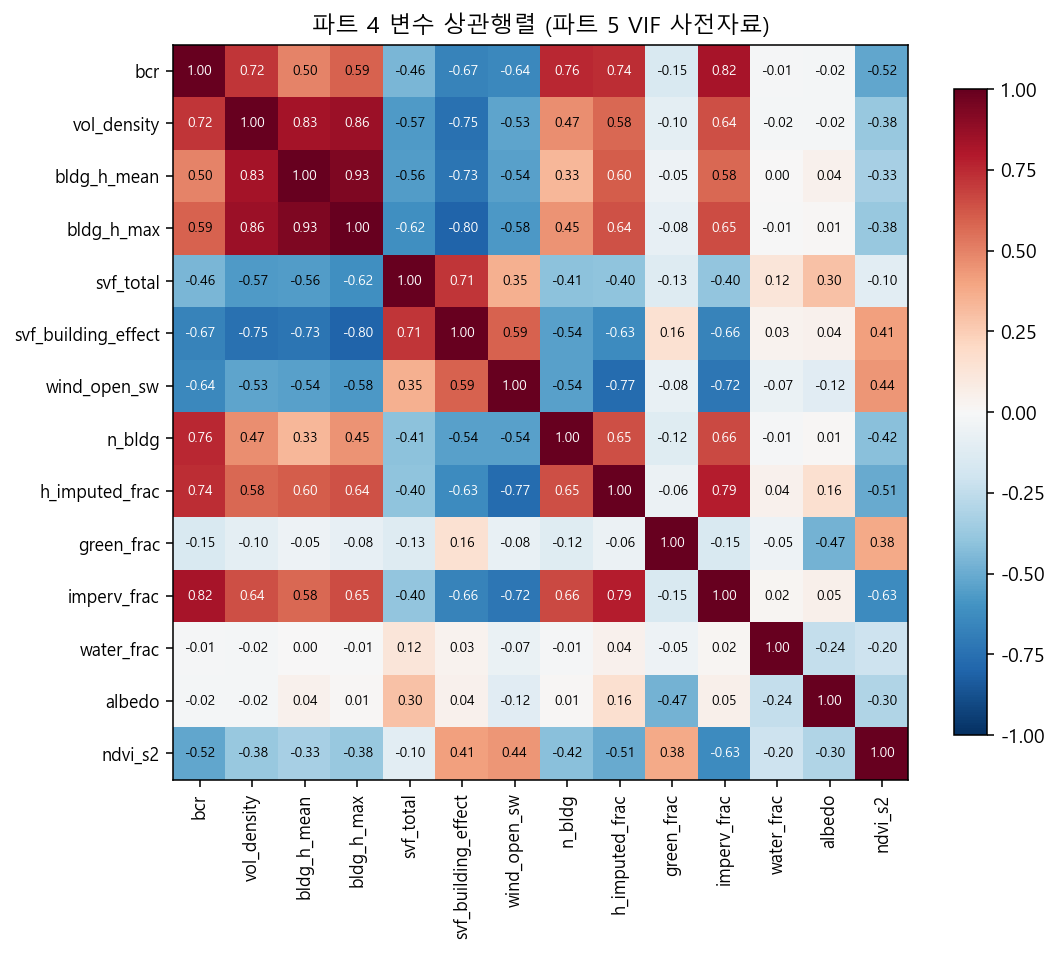


|r| > 0.8 조합 (파트 5에서 하나가 걸러질 가능성):
  bcr ↔ imperv_frac: +0.824
  vol_density ↔ bldg_h_mean: +0.832
  vol_density ↔ bldg_h_max: +0.859
  bldg_h_mean ↔ bldg_h_max: +0.934


In [30]:
import matplotlib
import matplotlib.pyplot as plt

for f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if f in {x.name for x in matplotlib.font_manager.fontManager.ttflist}:
        matplotlib.rcParams["font.family"] = f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

corr = pd.DataFrame()
if len(building_hex) or len(landcover_hex):
    joined = building_hex.merge(landcover_hex, on="hex_id", how="outer") \
        if len(building_hex) and len(landcover_hex) else (building_hex if len(building_hex) else landcover_hex)
    num = joined.select_dtypes("number").drop(columns=["lc_year"], errors="ignore")
    corr = num.corr()
    display(corr.round(2))

    fig, ax = plt.subplots(figsize=(8, 7), dpi=140)
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=9)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=9)
    for i in range(len(corr)):
        for j in range(len(corr)):
            v = corr.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if abs(v) > .6 else "black")
    fig.colorbar(im, shrink=.8)
    ax.set_title("파트 4 변수 상관행렬 (파트 5 VIF 사전자료)")
    fig.tight_layout()
    fig.savefig(OUT / "part4_corr_matrix.png")
    plt.show()

    # VIF 위험 후보 미리 표시
    high = [(a, b, corr.loc[a, b]) for i, a in enumerate(corr.columns)
            for b in corr.columns[i + 1:] if abs(corr.loc[a, b]) > 0.8]
    if high:
        print("\n|r| > 0.8 조합 (파트 5에서 하나가 걸러질 가능성):")
        for a, b, v in high:
            print(f"  {a} ↔ {b}: {v:+.3f}")
    META["correlation_high_pairs"] = [[a, b, float(v)] for a, b, v in high]

## 10. 검산 체크리스트 — 숫자가 상식과 맞는가

| 확인 항목 | 기대값 | 어긋나면 |
|---|---|---|
| BCR 최고 지역 | 서면·남포동·연산 등 고밀 시가지 0.4~0.6 | 격자 면적 분모 오류 또는 좌표계 어긋남 |
| 부피밀도 최고 지역 | 센텀·마린시티 등 고층 밀집지 | 높이 보정(층수×3m) 누락 |
| svf_total | 산복도로 골목 < 평지 저층 < 개활지 | DSM 해상도 문제 |
| green_frac 전체 | 40~50%대 (부산은 산이 많음) | 클래스 매핑 오류 |
| imperv ↔ NDVI | 뚜렷한 음의 상관 | 격자 정렬 오류 |
| 고령비율 상위 동 | 원도심(동구·서구·영도구) | 행정동 조인 오류 |
| 감률 민감도 | 야간 −0.496 대비 ±0.05 이내 | 녹지 마스크 정의 재검토 |

In [31]:
CHECK_POINTS = {   # 검산용 지점 (WGS84 lon, lat)
    "서면":        (129.0596, 35.1578),
    "남포동":      (129.0345, 35.0979),
    "연산":        (129.0830, 35.1793),
    "센텀시티":    (129.1290, 35.1690),
    "마린시티":    (129.1400, 35.1560),
    "산복도로(초량)": (129.0330, 35.1180),
    "금정산":      (129.0480, 35.2700),
}


def sample_at(arrays: dict, lon: float, lat: float) -> dict:
    tf = Transformer.from_crs(CRS_WGS84, CRS_GRID, always_xy=True)
    x, y = tf.transform(lon, lat)
    c = int((x - XMIN) // GRID_RES)
    r = int((YMAX - y) // GRID_RES)
    if not (0 <= r < GRID_H and 0 <= c < GRID_W):
        return {}
    return {k: float(v[r, c]) for k, v in arrays.items() if v is not None}


all_grids = {**bldg_grid, **svf_grid, **{k: v for k, v in lc_grid.items()}}
if all_grids:
    rows = []
    for name, (lon, lat) in CHECK_POINTS.items():
        s = sample_at(all_grids, lon, lat)
        if s:
            rows.append({"지점": name, **{k: round(v, 3) for k, v in s.items()}})
    display(pd.DataFrame(rows))

    print("\n판정:")
    dense = [r for r in rows if r["지점"] in ("서면", "남포동", "연산")]
    if dense and "bcr" in dense[0]:
        b = np.mean([r["bcr"] for r in dense])
        print(f"  고밀 시가지 평균 BCR {b:.3f} — {'✓ 0.4~0.6 기대범위' if 0.3 <= b <= 0.7 else '✗ 분모/좌표계 확인'}")
    tall = [r for r in rows if r["지점"] in ("센텀시티", "마린시티")]
    if tall and "vol_density" in tall[0]:
        v = np.mean([r["vol_density"] for r in tall])
        print(f"  고층 밀집지 평균 부피밀도 {v:.1f} m — 도시 전체 평균 "
              f"{np.nanmean(bldg_grid['vol_density']):.1f} m 보다 커야 정상")
    sanbok = [r for r in rows if r["지점"].startswith("산복도로")]
    open_ = [r for r in rows if r["지점"] == "금정산"]
    if sanbok and open_ and "svf_total" in sanbok[0]:
        print(f"  SVF 산복도로 {sanbok[0]['svf_total']:.3f} vs 개활지 {open_[0]['svf_total']:.3f} — "
              f"{'✓ 산복도로가 낮음' if sanbok[0]['svf_total'] < open_[0]['svf_total'] else '✗ DSM 해상도 확인'}")

,지점,bcr,vol_density,bldg_h_mean,bldg_h_max,n_bldg,h_imputed_frac,wind_open_sw,svf_total,svf_building_effect,green_frac,imperv_frac,water_frac,albedo,ndvi_s2
0,서면,0.05,1.11,22.200,33.0,6.0,1.0,0.034,0.775,-0.206,0.12,0.88,0.0,0.138,0.204
1,남포동,0.22,4.02,18.273,42.0,22.0,1.0,0.258,0.700,-0.276,0.01,0.99,0.0,0.131,0.083
2,연산,0.01,0.09,9.000,9.0,6.0,1.0,0.092,0.935,-0.034,0.44,0.56,0.0,0.161,0.376
3,센텀시티,0.32,11.76,36.750,42.0,0.0,0.0,0.128,0.769,-0.204,0.21,0.79,0.0,0.145,0.188
4,마린시티,0.00,0.00,0.000,0.0,0.0,0.0,1.000,0.971,-0.016,0.00,0.00,1.0,0.060,-0.064
5,산복도로(초량),0.41,2.85,6.951,15.0,53.0,1.0,0.106,0.683,-0.122,0.13,0.87,0.0,0.139,0.140
6,금정산,0.00,0.00,0.000,0.0,0.0,0.0,1.000,0.842,-0.026,1.00,0.00,0.0,0.120,0.826



판정:
  고밀 시가지 평균 BCR 0.093 — ✗ 분모/좌표계 확인
  고층 밀집지 평균 부피밀도 5.9 m — 도시 전체 평균 0.2 m 보다 커야 정상
  SVF 산복도로 0.683 vs 개활지 0.842 — ✓ 산복도로가 낮음


### 10-1. 완충대 제외 검산 (2026-08-16 추가)

위 cell13의 "green_frac 도시 전체 평균 14.4%"와 building_hex의 `svf_building_effect` 결측 30%는 버그가 아니라 **파트1이 LISA/GWR 가장자리 추정용으로 남겨둔 완충대(`in_busan=False`, 151,440개 중 84,434개)를 그대로 포함해서 평균낸 착시**다. 완충대는 토지피복·지형 원본 자체가 없는 범위라 당연히 0/NaN이 된다. `in_busan=True`(파트1의 실제 분석 대상, 67,006개)만 걸러서 다시 보면:

In [32]:
hex_flag = pd.read_parquet(PATH_HEX, columns=["hex_id", "in_busan"])
chk = hex_flag.merge(landcover_hex, on="hex_id", how="inner").merge(building_hex, on="hex_id", how="inner")
busan_only = chk[chk["in_busan"] == True]

print(f"in_busan=True hex: {len(busan_only):,} / 전체 {len(chk):,}")
print(f"green_frac 평균 (부산 실지역만): {busan_only.green_frac.mean():.1%}  (가이드라인 기대 40~50%대)")
print(f"imperv_frac 평균 (부산 실지역만): {busan_only.imperv_frac.mean():.1%}")
print(f"albedo 결측 (부산 실지역만): {busan_only.albedo.isna().sum():,} / {len(busan_only):,}")
print(f"svf_building_effect 결측 (부산 실지역만): "
      f"{busan_only.svf_building_effect.isna().sum():,} / {len(busan_only):,} "
      f"({busan_only.svf_building_effect.isna().mean():.1%})")

g_ok = 0.40 <= busan_only.green_frac.mean() <= 0.55
green_ok_label = "기대범위 근접" if g_ok else "여전히 벗어남 -- 완충대 외 다른 원인 의심"
print("판정: green_frac " + green_ok_label)

if "ndvi_s2" in busan_only.columns:
    r_iv = busan_only.imperv_frac.corr(busan_only.ndvi_s2)
    r_gv = busan_only.green_frac.corr(busan_only.ndvi_s2)
    print(f"imperv-NDVI 상관 (부산 실지역만): {r_iv:.3f}  (cell13의 격자 전체 기준은 완충대 포함 착시)")
    print(f"green_frac-NDVI 상관 (부산 실지역만): {r_gv:.3f} (참고)")
    ndvi_ok_label = "뚜렷한 음의 상관" if r_iv < -0.4 else "여전히 약함"
    print("판정: imperv-NDVI " + ndvi_ok_label)


in_busan=True hex: 67,006 / 전체 151,440
green_frac 평균 (부산 실지역만): 53.6%  (가이드라인 기대 40~50%대)
imperv_frac 평균 (부산 실지역만): 28.6%
albedo 결측 (부산 실지역만): 0 / 67,006
svf_building_effect 결측 (부산 실지역만): 1,715 / 67,006 (2.6%)
판정: green_frac 기대범위 근접
imperv-NDVI 상관 (부산 실지역만): -0.834  (cell13의 격자 전체 기준은 완충대 포함 착시)
green_frac-NDVI 상관 (부산 실지역만): 0.883 (참고)
판정: imperv-NDVI 뚜렷한 음의 상관


In [33]:
(OUT / "part4_meta.json").write_text(
    json.dumps(META, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("saved:", OUT / "part4_meta.json")

saved: ..\data\part4\processed\part4_meta.json


## 11. 파트 2 · 5 인터페이스

- **파트 2에서 받는 것** — 정밀 DEM(DSM 제작용), `svf_terrain`(건물분 분리용).
  파트 2보다 먼저 SVF를 만들 수는 없으므로, 건물 전처리(1~2단계)와 피복(5단계)을 먼저 진행하며 기다린다.
- **파트 3과 겹치는 것** — 없음. 완전히 병렬 진행 가능.
- **파트 5에 넘기는 것** — 산출물 4개.
  - 모델 1(평지형 표준모델) = `bcr + vol_density + ndvi_s2(또는 green_frac) + imperv_frac + dist_water_m(파트1)`
  - `svf_total · wind_open_sw` 는 모델 2(지형 포함)에서 파트 2 변수와 함께

> ### ⚠️ 마지막 경고 — 순환논리 금지
> `elev_m`(표고)은 anomaly 생성에 이미 사용됐으므로 **어떤 회귀에도 설명변수로 넣지 않는다.**
> hex 테이블에 컬럼이 남아 있어 무심코 넣기 쉽다. 파트 4 산출물에는 표고를 아예 포함하지 않는다.

In [34]:
# 순환논리 방지 — 산출물에 표고 계열 컬럼이 새어 들어갔는지 최종 확인
BANNED = ("elev", "dem", "altitude", "표고", "고도")
for name, df in (("building_hex", building_hex), ("landcover_hex", landcover_hex)):
    if len(df):
        leaked = [c for c in df.columns if any(b in c.lower() for b in BANNED)]
        assert not leaked, f"{name}에 표고 계열 컬럼 유출: {leaked} — 순환논리 위험"
        print(f"[ok] {name}: 표고 컬럼 없음 ({len(df)}행 × {df.shape[1]}열)")
print("\n파트 4 전처리 완료.")

[ok] building_hex: 표고 컬럼 없음 (151440행 × 10열)
[ok] landcover_hex: 표고 컬럼 없음 (151440행 × 7열)

파트 4 전처리 완료.
